## Imports & paths

In [1]:
import socket, os
print(socket.gethostname())
print(os.getcwd())

LAPTOP-RLFB5OCF
/home/lois/pypsa-eur/pypsa-eur/scripts/_testing


In [1]:
import pypsa
import numpy as np
import pandas as pd
import xarray as xr
import yaml
import re
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.signal import detrend

root = Path.cwd()
pypsa_eur_root    = root / "projects/pypsa-eur"
pypsa_eur_scripts = pypsa_eur_root / "scripts"

sys.path.insert(0, str(pypsa_eur_root))
sys.path.insert(0, str(pypsa_eur_scripts))
sys.path.insert(0, str(pypsa_eur_scripts / "_testing"))

## Configuration

In [2]:
CONFIG_PATH       = pypsa_eur_root / "config/config.FR-summer_years+dmg_nucl.yaml"
DMG_CONFIG_PATH   = pypsa_eur_root / "config/damage_config.yaml"
CLUSTERS          = 5
CF_ACTUAL_DIR     = pypsa_eur_root / "scripts/_testing/entsoe_data"
CF_ACTUAL_PATTERN = "cf_B14_plant_{year}-01-01_{year}-12-31.csv"
cf_fixed_factor   = 0.616
SCENARIO_GLOB     = "weather_year_*_dmg_cap"

In [7]:
CONFIG_PATH       = pypsa_eur_root / "config/config.2022-FR+dmg_nucl.yaml"
DMG_CONFIG_PATH   = pypsa_eur_root / "config/damage_config.yaml"
CLUSTERS          = 5
CF_ACTUAL_DIR     = pypsa_eur_root / "scripts/_testing/entsoe_data"
CF_ACTUAL_PATTERN = "cf_B14_plant_{year}-01-01_{year}-12-31.csv"
cf_fixed_factor   = 0.616
SCENARIO_GLOB     = "weather_year_*_nuc_cap"


## Load scenarios

In [6]:
from scripts.build_damage_profiles.build_nuclear_damage_profiles import load_nuclear_plants

with open(CONFIG_PATH) as f:
    cfg = yaml.safe_load(f)
with open(DMG_CONFIG_PATH) as f:
    dmg_cfg = yaml.safe_load(f)

_prefix           = cfg["run"].get("prefix", "")
SCENARIO_BASE_DIR = pypsa_eur_root / "resources" / _prefix


def _base_name(name: str) -> str:
    return re.sub(r"\s+\d+$", "", name.strip().upper())


def _build_mapping(powerplants_df: pd.DataFrame, cf_actual: pd.DataFrame) -> pd.DataFrame:
    unit_names = cf_actual.unit_name.unique()
    rows = []
    for pp_name in powerplants_df["Name"]:
        base    = _base_name(pp_name)
        matched = [u for u in unit_names if u.startswith(base)]
        for unit in matched:
            rows.append({"Name": pp_name, "unit_name": unit})
    return pd.DataFrame(rows).sort_values("Name").reset_index(drop=True)


def load_scenario(scenario_dir: Path) -> dict:
    year = int(re.search(r"weather_year_(\d+)_dmg", scenario_dir.name).group(1))
    powerplants_df = load_nuclear_plants(scenario_dir / f"powerplants_s_{CLUSTERS}.csv")
    plant_nc  = scenario_dir / "damage_profiles" / "nuclear_damage_plants.nc"
    damage_df = xr.open_dataset(plant_nc)["profile"].to_pandas()
    cf_actual = pd.read_csv(
        CF_ACTUAL_DIR / CF_ACTUAL_PATTERN.format(year=year),
        index_col=0, parse_dates=True,
    )
    mapping = _build_mapping(powerplants_df, cf_actual)
    return {
        "year":           year,
        "scenario_dir":   scenario_dir,
        "damage_df":      damage_df,
        "powerplants_df": powerplants_df,
        "cf_actual":      cf_actual,
        "mapping":        mapping,
    }


scenario_dirs = sorted(SCENARIO_BASE_DIR.glob(SCENARIO_GLOB))
scenarios     = [load_scenario(d) for d in scenario_dirs]
powerplants_df = scenarios[-1]["powerplants_df"]

print(f"Found {len(scenarios)} scenarios: {[s['year'] for s in scenarios]}")


Found 5 scenarios: [2018, 2019, 2020, 2021, 2022]


## CF loading and gap filling

In [7]:
from builders import fill_short_gaps

CF_DOWN_THRESHOLD = 0.1
cf_filled_by_year     = {}
active_plants_by_year = {}
mapping_by_year       = {}

for s in scenarios:
    year         = s["year"]
    summer_start = f"{year}-06-01"
    summer_end   = f"{year}-08-31"
    cf_norm      = s["cf_actual"].copy()
    cf_norm.index = pd.to_datetime(cf_norm.index, utc=True).tz_convert(None)
    cf_norm = cf_norm.sort_index()

    unit_mean = (
        cf_norm.loc[summer_start:summer_end]
        .groupby("unit_name")["capacity_factor"].mean()
    )
    plant_unit = s["mapping"].copy()
    plant_unit["mean_summer_cf"] = plant_unit["unit_name"].map(unit_mean)
    plant_mean = plant_unit.dropna(subset=["mean_summer_cf"]).groupby("Name")["mean_summer_cf"].mean()

    active = plant_mean[plant_mean >= CF_DOWN_THRESHOLD].index.tolist()
    active_units = s["mapping"].loc[s["mapping"]["Name"].isin(active), "unit_name"].tolist()
    cf_active = s["cf_actual"][s["cf_actual"]["unit_name"].isin(active_units)].copy()

    cf_filled_by_year[year]     = fill_short_gaps(cf_active)
    active_plants_by_year[year] = active
    mapping_by_year[year]       = s["mapping"]
    print(f"{year}: {len(active)} active plants: {active}")

2018: 19 active plants: ['Belleville 6', 'Blayais 3', 'Bugey 3', 'Cattenom', 'Chinon', 'Chooz 2', 'Civaux', 'Cruas 4', 'Dampierre 5', 'Fessenheim 3', 'Flamanville 2', 'Golfech 2', 'Gravelines 7', 'Nogent', 'Paluel 2', 'Penly 3', 'St Alban', 'St Laurent 4', 'Tricastin 2']
2019: 18 active plants: ['Belleville 6', 'Blayais 3', 'Bugey 3', 'Cattenom', 'Chinon', 'Chooz 2', 'Civaux', 'Cruas 4', 'Dampierre 5', 'Flamanville 2', 'Golfech 2', 'Gravelines 7', 'Nogent', 'Paluel 2', 'Penly 3', 'St Alban', 'St Laurent 4', 'Tricastin 2']
2020: 17 active plants: ['Belleville 6', 'Blayais 3', 'Bugey 3', 'Cattenom', 'Chinon', 'Chooz 2', 'Civaux', 'Cruas 4', 'Dampierre 5', 'Golfech 2', 'Gravelines 7', 'Nogent', 'Paluel 2', 'Penly 3', 'St Alban', 'St Laurent 4', 'Tricastin 2']
2021: 18 active plants: ['Belleville 6', 'Blayais 3', 'Bugey 3', 'Cattenom', 'Chinon', 'Chooz 2', 'Civaux', 'Cruas 4', 'Dampierre 5', 'Flamanville 2', 'Golfech 2', 'Gravelines 7', 'Nogent', 'Paluel 2', 'Penly 3', 'St Alban', 'St Laur

In [8]:
mapping_by_year[2022]


,Name,unit_name
0,Belleville 6,BELLEVILLE 2
1,Belleville 6,BELLEVILLE 1
2,Blayais 3,BLAYAIS 4
3,Blayais 3,BLAYAIS 2
4,Blayais 3,BLAYAIS 1
5,Blayais 3,BLAYAIS 3
6,Bugey 3,BUGEY 5
7,Bugey 3,BUGEY 4
8,Bugey 3,BUGEY 3
9,Bugey 3,BUGEY 2


## CF demeaning (per hour-of-day)

In [9]:
def demean_by_hour(df):
    hourly_means = df.groupby(df.index.hour).transform("mean")
    return df - hourly_means

cf_demeaned_by_year = {}

for s in scenarios:
    year         = s["year"]
    summer_start = f"{year}-06-01"
    summer_end   = f"{year}-08-31"
    plants       = active_plants_by_year[year]
    cf_filled    = cf_filled_by_year[year]
    mapping      = mapping_by_year[year]

    cf_chunks = {}
    cf_src = cf_filled.loc[summer_start:summer_end]

    for plant in plants:
        units = mapping.loc[mapping["Name"] == plant, "unit_name"].tolist()
        sub   = cf_src[cf_src["unit_name"].isin(units)]
        if sub.empty:
            continue
        pivot = sub.pivot_table(index=sub.index, columns="unit_name", values="capacity_factor")
        caps  = sub.groupby("unit_name")["installed_capacity_mw"].first()
        cf_chunks[plant] = pivot.mul(caps).sum(axis=1) / caps.sum()

    cf_demeaned_by_year[year] = demean_by_hour(pd.DataFrame(cf_chunks))

print("cf_demeaned_by_year built for years:", list(cf_demeaned_by_year.keys()))

cf_demeaned_by_year built for years: [2018, 2019, 2020, 2021, 2022]


## Analysis: CF drop events and hot lake temperatures

### Step 0 - DWT P90 temperature whole year 

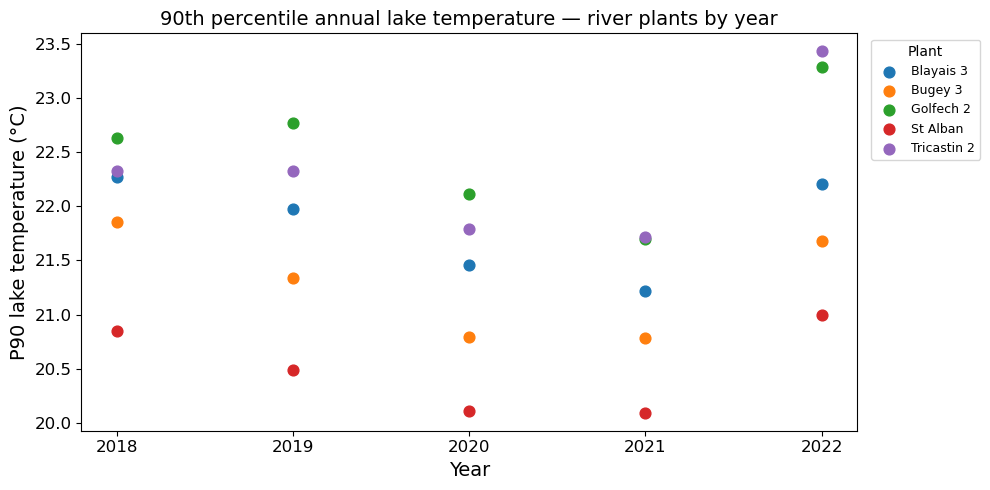

In [96]:
lake_temps_full = pd.read_csv(
    pypsa_eur_root / "scripts/_testing/whole_year_lake_temps.csv",
    parse_dates=["snapshot"],
)

def _base_name(name: str) -> str:
    return re.sub(r"\s+\d+$", "", name.strip().lower())

river_base_map = {_base_name(p): p for p in plant_river_list}

records = []
for (year, plant), grp in lake_temps_full.groupby(["year", "plant"]):
    base = _base_name(plant)
    if base not in river_base_map:
        continue
    records.append({"year": year, "plant": river_base_map[base], "p90": grp["lake_temp_c"].quantile(0.9)})

p90_df = pd.DataFrame(records).pivot(index="year", columns="plant", values="p90")

fig, ax = plt.subplots(figsize=(10, 5))
for plant in p90_df.columns:
    ax.scatter(p90_df.index, p90_df[plant], label=plant, s=60)
ax.set_xticks(p90_df.index)
ax.set_xticklabels(p90_df.index.astype(int))
ax.set_xlabel("Year")
ax.set_ylabel("P90 lake temperature (°C)")
ax.set_title("90th percentile annual lake temperature — river plants by year")
ax.legend(title="Plant", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()


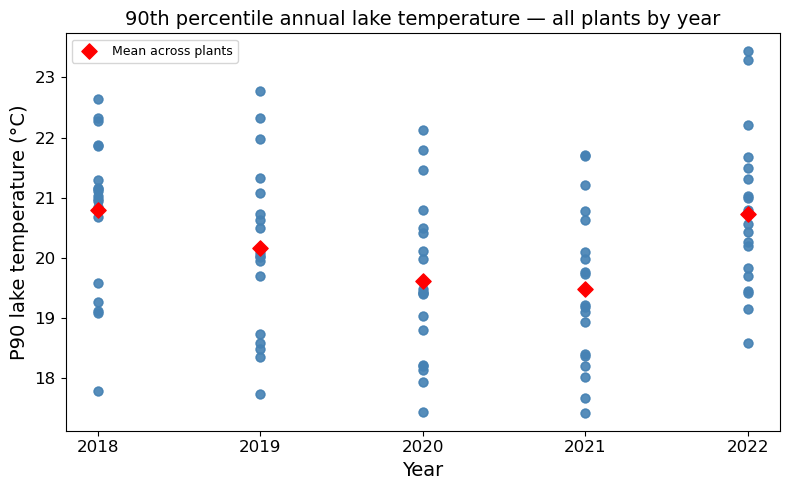

In [100]:
records_all = []
for (year, plant), grp in lake_temps_full.groupby(["year", "plant"]):
    records_all.append({"year": year, "plant": plant, "p90": grp["lake_temp_c"].quantile(0.9)})

p90_all_df = pd.DataFrame(records_all).pivot(index="year", columns="plant", values="p90")

fig, ax = plt.subplots(figsize=(8, 5))
for plant in p90_all_df.columns:
    ax.scatter(p90_all_df.index, p90_all_df[plant], color="steelblue", s=40, alpha=0.7)

for plant in p90_all_df.columns:
    ax.scatter(p90_all_df.index, p90_all_df[plant], color="steelblue", s=40, alpha=0.7)

for year, row in p90_all_df.iterrows():
    ax.scatter(year, row.mean(), color="red", s=60, zorder=5, marker="D")

ax.set_xticks(p90_all_df.index)
ax.set_xticklabels(p90_all_df.index.astype(int))
ax.set_xlabel("Year")
ax.set_ylabel("P90 lake temperature (°C)")
ax.set_title("90th percentile annual lake temperature — all plants by year")
ax.scatter([], [], color="red", s=60, marker="D", label="Mean across plants")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


### Step 1 — Raw summer temperature baselines (per plant, per year)

In [10]:
LAKE_TEMPS_CSV = pypsa_eur_root / "scripts/_testing/whole_year_lake_temps.csv"
lake_temps_df  = pd.read_csv(LAKE_TEMPS_CSV, parse_dates=["snapshot"])

temp_stats              = {}  # temp_stats[year][plant] = (mean, std)
raw_summer_temp_by_year = {}  # raw_summer_temp_by_year[year][plant] = pd.Series (°C)

for year in [s["year"] for s in scenarios]:
    year_df   = lake_temps_df[lake_temps_df["year"] == year]
    summer_df = year_df[year_df["snapshot"].dt.month.isin([6, 7, 8])]
    temp_stats[year]              = {}
    raw_summer_temp_by_year[year] = {}
    for plant, grp in summer_df.groupby("plant"):
        series = grp.set_index("snapshot")["lake_temp_c"].sort_index()
        raw_summer_temp_by_year[year][plant] = series
        temp_stats[year][plant] = (series.mean(), series.std())

print("Temperature baselines loaded from CSV.")


Temperature baselines loaded from CSV.


In [11]:
temp_stats[2022]

{'Belleville 6': (np.float64(19.756317844202897), 1.573273973967083),
 'Blayais 3': (np.float64(21.634697644927538), 1.561305128761315),
 'Bugey 3': (np.float64(20.833167481884058), 2.4365473574553063),
 'Cattenom': (np.float64(19.22777545289855), 1.7532958463931314),
 'Chinon': (np.float64(19.959763043478258), 1.7174725173702872),
 'Chooz 2': (np.float64(18.403333967391305), 2.499835094058485),
 'Civaux': (np.float64(20.418505480072465), 2.6684547836254593),
 'Cruas 4': (np.float64(20.249727536231884), 2.941997252095811),
 'Dampierre 5': (np.float64(19.780053125000002), 1.6228786141221705),
 'Fessenheim 3': (np.float64(20.805052536231884), 1.7438455458361484),
 'Flamanville 2': (np.float64(17.288854981884057), 1.6024179186725949),
 'Golfech 2': (np.float64(22.644045063405798), 2.340576477528955),
 'Gravelines 7': (np.float64(18.421188088768115), 2.0063030501819368),
 'Nogent': (np.float64(20.0067772192029), 2.4945856865975022),
 'Paluel 2': (np.float64(18.580131114130435), 2.057861402

#### Visual check of Historical nuclear CF vs Lake temp in nearest cell 

Plotting: Belleville 6 — 2022


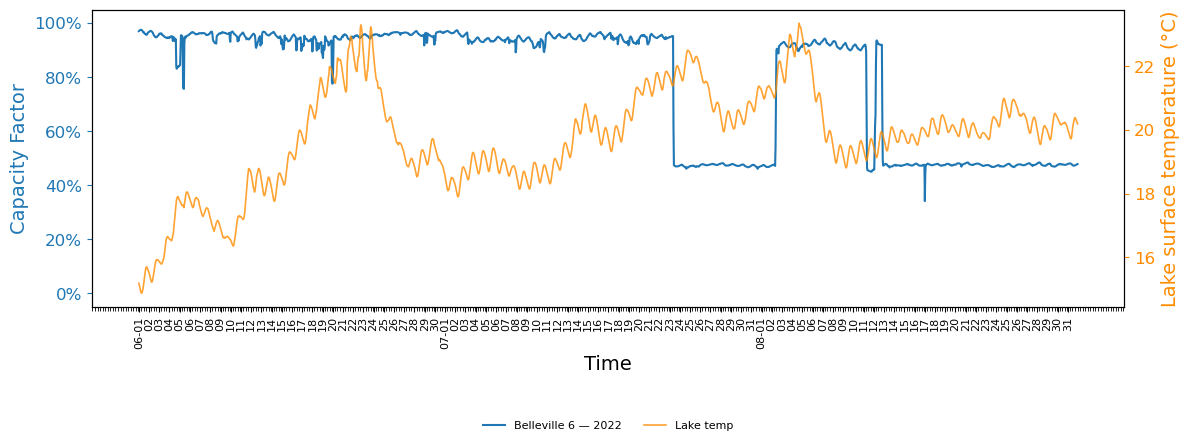

Plotting: Blayais 3 — 2022


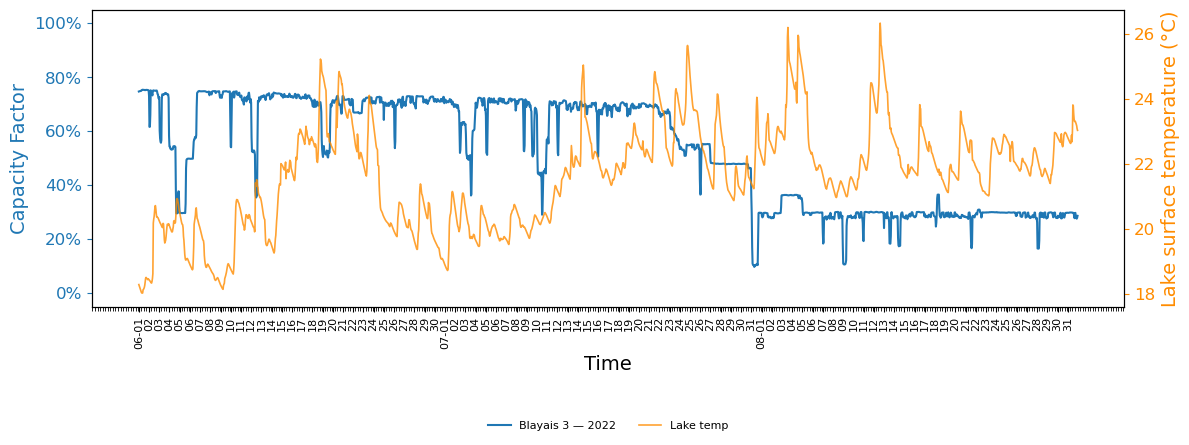

Plotting: Bugey 3 — 2022


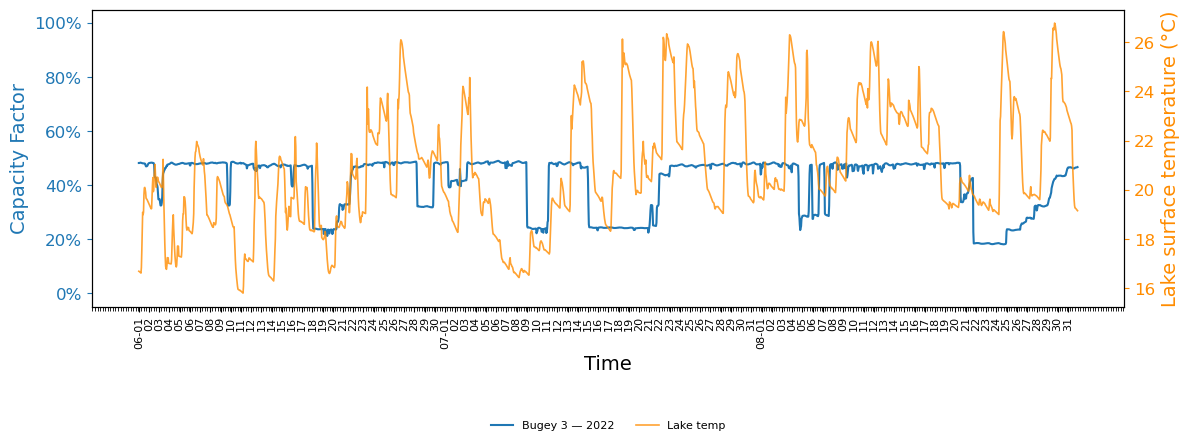

Plotting: Cattenom — 2022


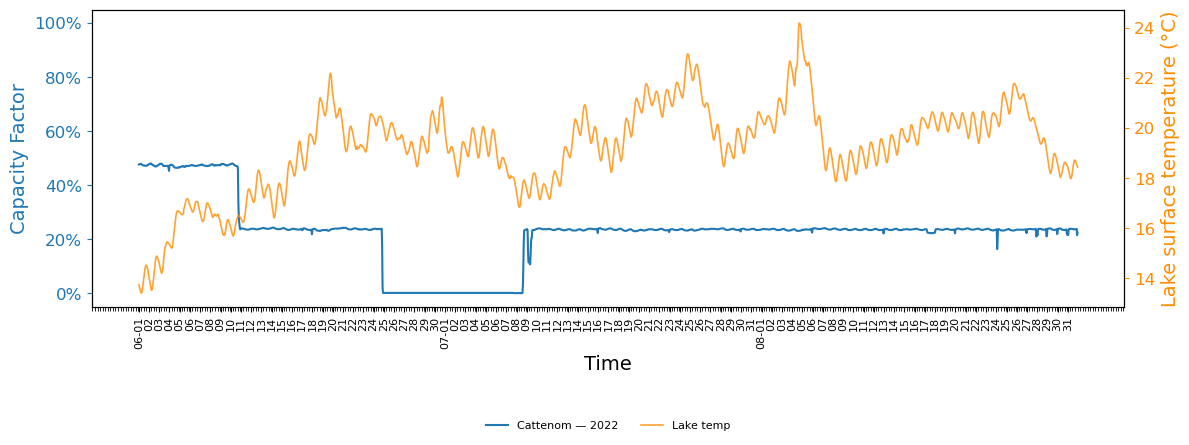

Plotting: Chinon — 2022


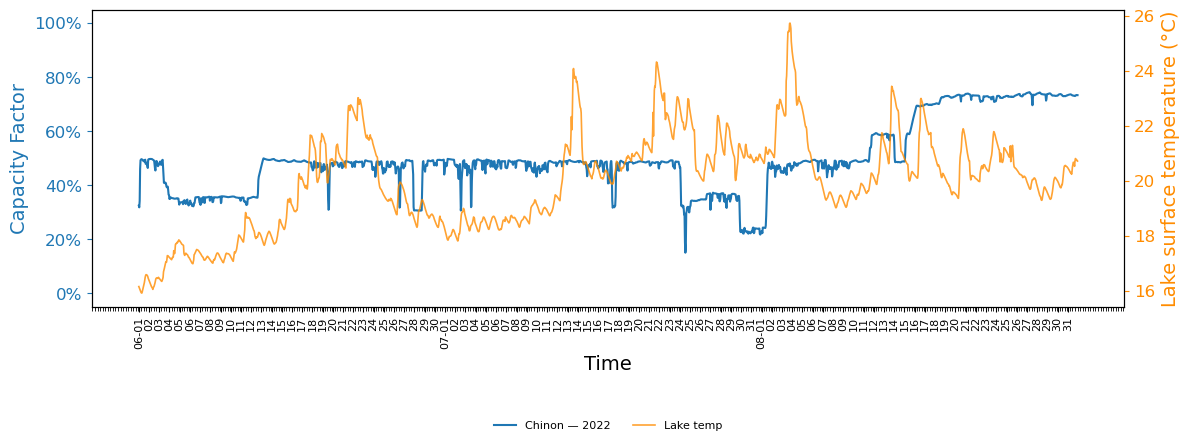

Plotting: Cruas 4 — 2022


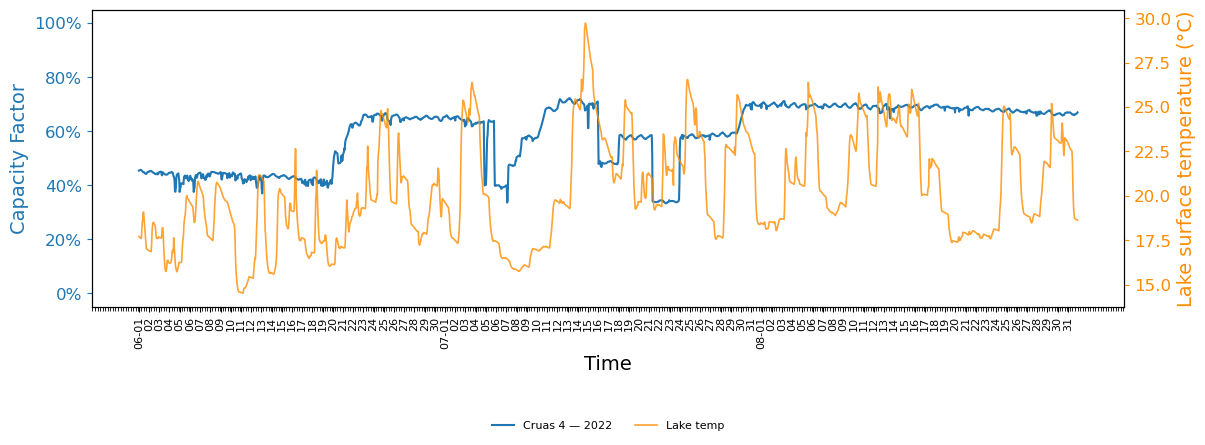

Plotting: Dampierre 5 — 2022


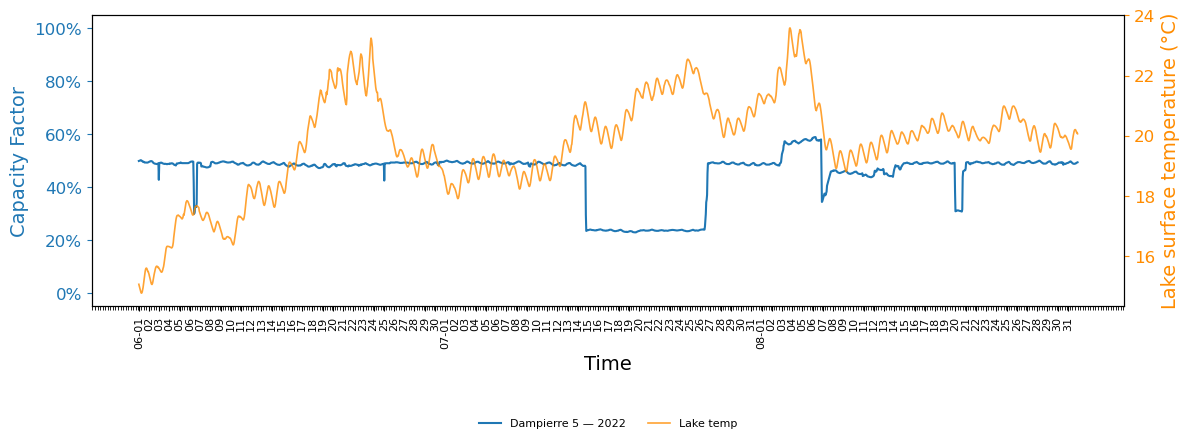

Plotting: Golfech 2 — 2022


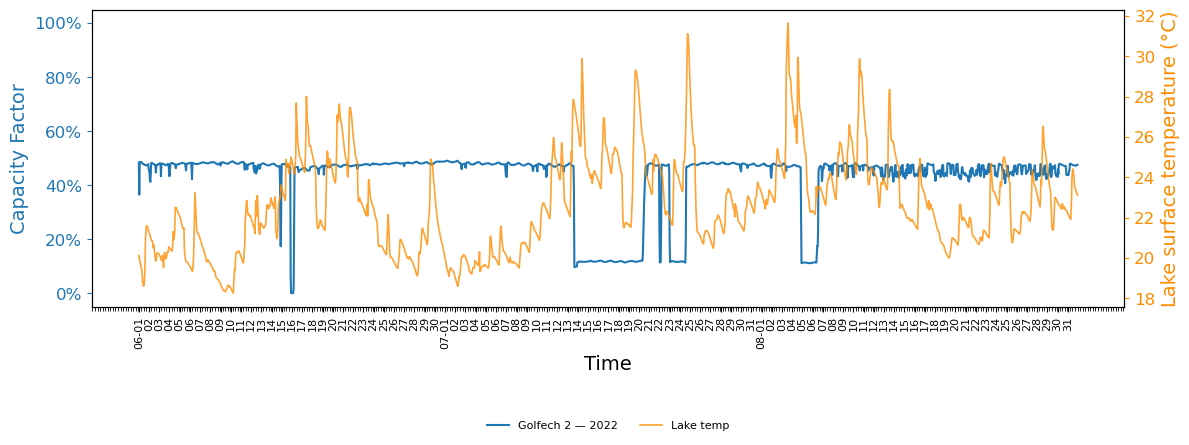

Plotting: Gravelines 7 — 2022


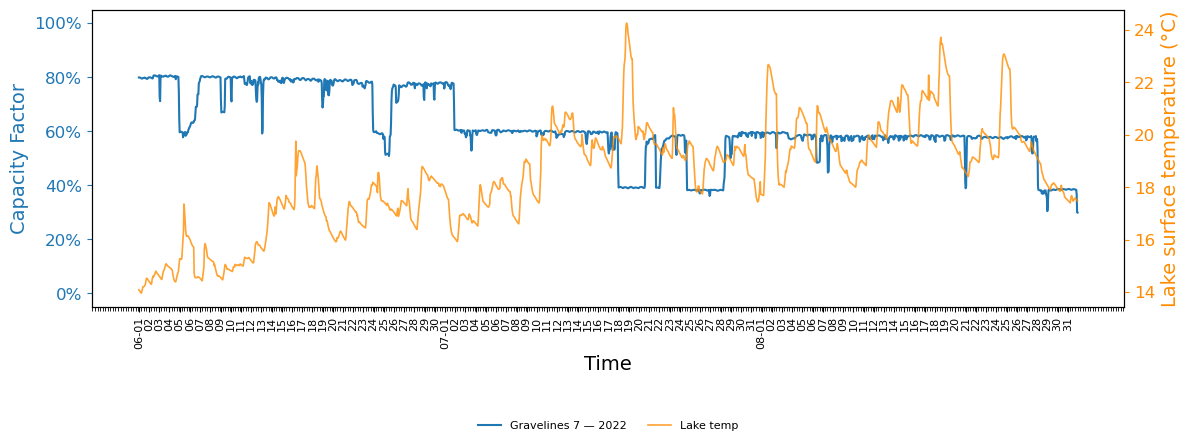

Plotting: Nogent — 2022


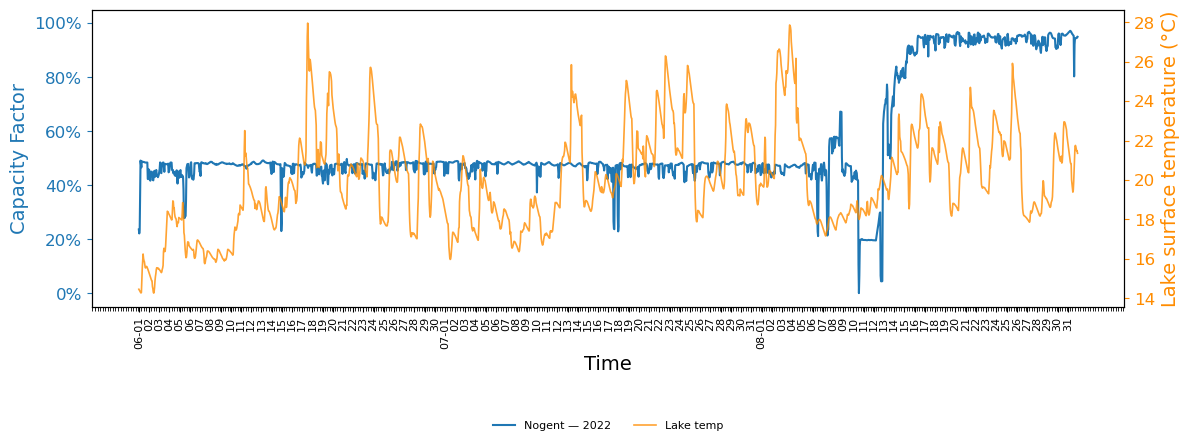

Plotting: Paluel 2 — 2022


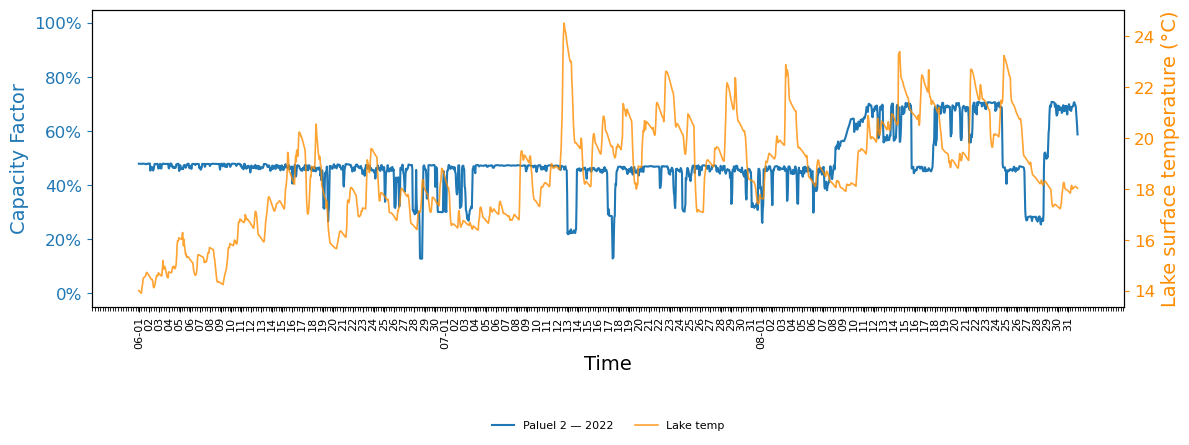

Plotting: Penly 3 — 2022


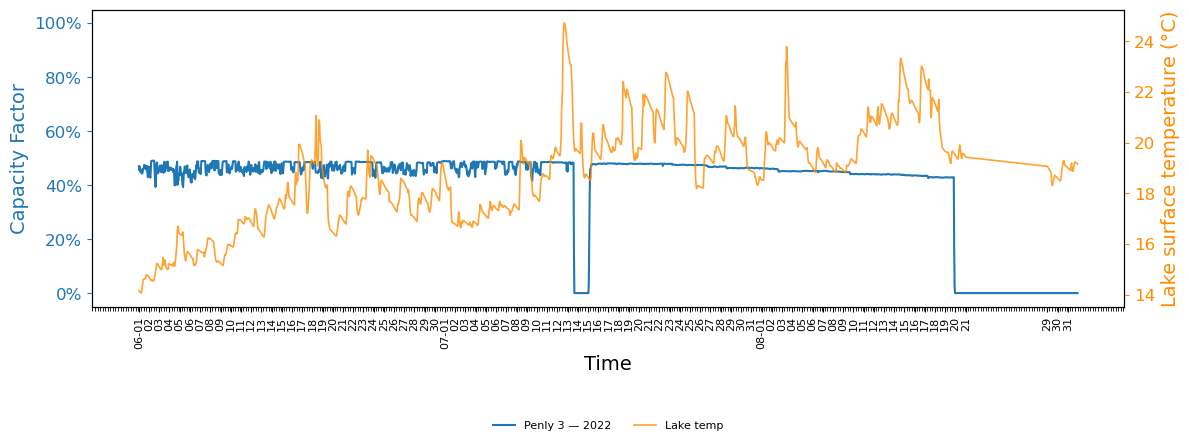

Plotting: St Alban — 2022


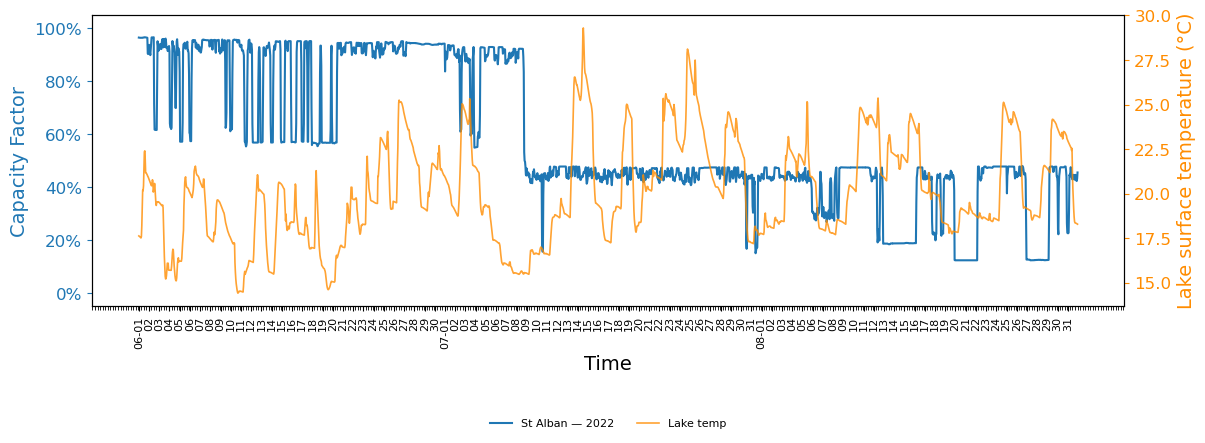

Plotting: St Laurent 4 — 2022


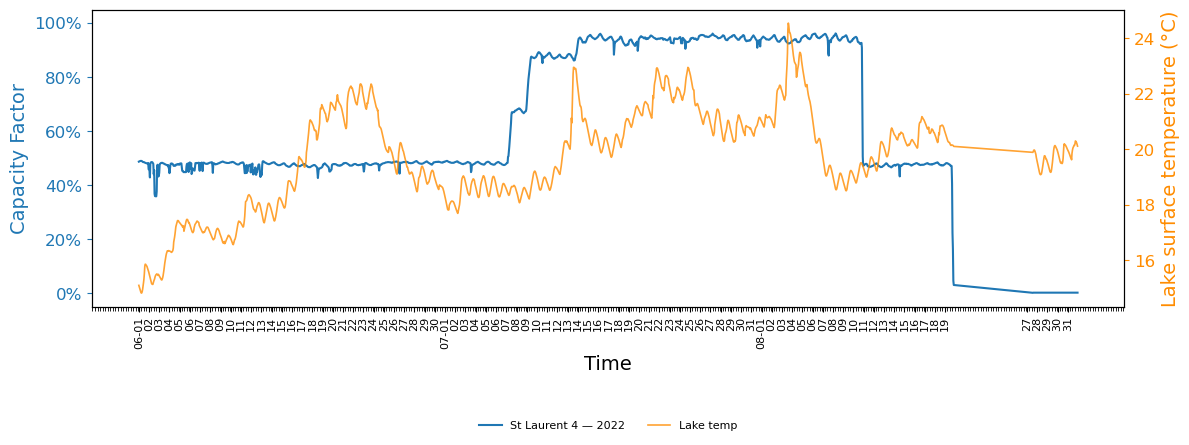

Plotting: Tricastin 2 — 2022


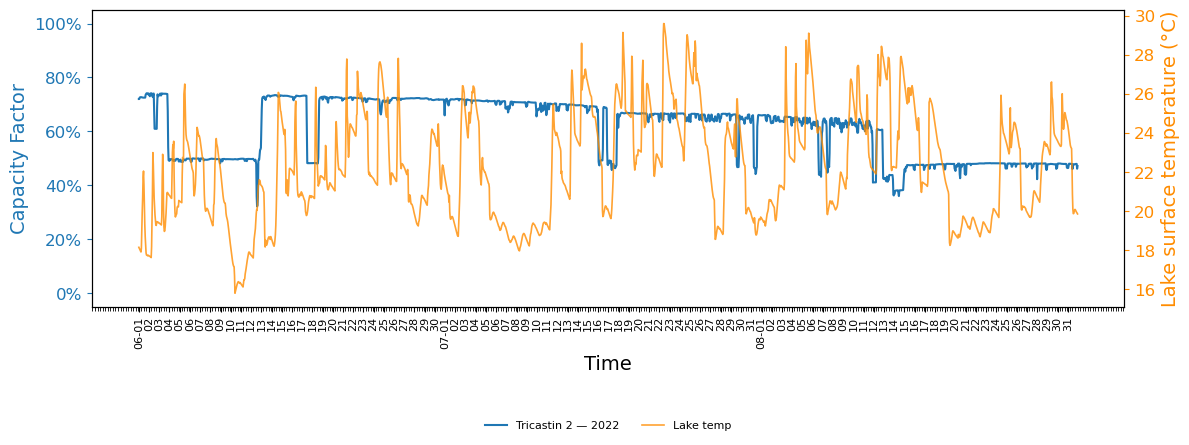

In [153]:
from plot_damage import plot_plant_profile

YEAR         = 2022
summer_start = f"{YEAR}-06-01"
summer_end   = f"{YEAR}-08-31"
cf_src       = cf_filled_by_year[YEAR].loc[summer_start:summer_end]
mapping      = mapping_by_year[YEAR]

for plant in active_plants_by_year[YEAR]:
    if plant not in raw_summer_temp_by_year[YEAR]:
        continue
    units = mapping.loc[mapping["Name"] == plant, "unit_name"].tolist()
    sub   = cf_src[cf_src["unit_name"].isin(units)]
    if sub.empty:
        continue
    pivot = sub.pivot_table(index=sub.index, columns="unit_name", values="capacity_factor")
    caps  = sub.groupby("unit_name")["installed_capacity_mw"].first()
    cf    = pivot.mul(caps).sum(axis=1) / caps.sum()

    temps    = raw_summer_temp_by_year[YEAR][plant].reindex(cf.index, method="nearest")
    plant_df = pd.DataFrame({"availability": cf.values, "temp_c": temps.values}, index=cf.index)

    print(f"Plotting: {plant} — {YEAR}")
    fig, (ax1, ax2) = plot_plant_profile(plant_df, title=f"{plant} — {YEAR}", show_thresholds=False)
    ax1.set_ylabel("Capacity Factor")
    plt.show()


### Step 2 — Identify CF drop events (diff < mean − 2σ, per plant per year)

In [12]:
events_by_plant = {}  # plant -> list of (timestamp, diff_value, year)

for s in scenarios:
    year   = s["year"]
    cf_dem = cf_demeaned_by_year[year]

    for plant in cf_dem.columns:
        diffs     = cf_dem[plant].diff().dropna()
        threshold = diffs.mean() - 2 * diffs.std()
        event_times = diffs[diffs < threshold].index

        if plant not in events_by_plant:
            events_by_plant[plant] = []
        for t in event_times:
            events_by_plant[plant].append((t, float(diffs[t]), year))

for plant, evs in events_by_plant.items():
    print(f"{plant}: {len(evs)} events")

Belleville 6: 100 events
Blayais 3: 174 events
Bugey 3: 144 events
Cattenom: 162 events
Chinon: 216 events
Chooz 2: 79 events
Civaux: 58 events
Cruas 4: 180 events
Dampierre 5: 105 events
Fessenheim 3: 21 events
Flamanville 2: 80 events
Golfech 2: 156 events
Gravelines 7: 198 events
Nogent: 125 events
Paluel 2: 219 events
Penly 3: 150 events
St Alban: 166 events
St Laurent 4: 112 events
Tricastin 2: 152 events


### Step 3 — Extract ±36h temp windows and qualify hot timepoints (temp > mean + 2σ)

In [13]:
scatter_by_plant = {}  # plant -> list of (temp_value, diff_value, year)

for s in scenarios:
    year   = s["year"]
    plants = active_plants_by_year[year]

    for _, row in s["powerplants_df"][s["powerplants_df"]["Name"].isin(plants)].iterrows():
        plant = row["Name"]

        if plant not in events_by_plant:
            continue
        if plant not in raw_summer_temp_by_year[year]:
            continue

        temp_mean, temp_std = temp_stats[year][plant]
        hot_threshold = temp_mean + 2 * temp_std
        summer_temps  = raw_summer_temp_by_year[year][plant]

        plant_year_events = [(t, dv) for t, dv, yr in events_by_plant[plant] if yr == year]

        if plant not in scatter_by_plant:
            scatter_by_plant[plant] = []

        # Each qualifying temperature timestamp is assigned to its nearest event
        # so overlapping windows don't double-count the same observation.
        seen: dict = {}  # ts -> (temp_val, diff_val, distance_seconds)
        for t, diff_val in plant_year_events:
            w_start = t - pd.Timedelta("36h")
            w_end   = t + pd.Timedelta("36h")
            qualifying = summer_temps.loc[w_start:w_end]
            qualifying = qualifying[qualifying > hot_threshold]
            for ts, temp_val in qualifying.items():
                dist = abs((ts - t).total_seconds())
                if ts not in seen or dist < seen[ts][2]:
                    seen[ts] = (float(temp_val), diff_val, dist)

        for temp_val, diff_val, _ in seen.values():
            scatter_by_plant[plant].append((temp_val, diff_val, year))

for plant, pts in scatter_by_plant.items():
    print(f"{plant}: {len(pts)} scatter points")


Nogent: 98 scatter points
Paluel 2: 92 scatter points
Penly 3: 85 scatter points
St Alban: 104 scatter points
Tricastin 2: 111 scatter points
St Laurent 4: 83 scatter points
Dampierre 5: 123 scatter points
Belleville 6: 39 scatter points
Gravelines 7: 195 scatter points
Bugey 3: 109 scatter points
Cattenom: 106 scatter points
Chinon: 194 scatter points
Chooz 2: 26 scatter points
Civaux: 69 scatter points
Cruas 4: 139 scatter points
Fessenheim 3: 22 scatter points
Flamanville 2: 0 scatter points
Golfech 2: 139 scatter points
Blayais 3: 161 scatter points


In [111]:
import csv

rows = []
for plant, points in scatter_by_plant.items():
    for temp_val, diff_val, year in points:
        rows.append({"plant": plant, "year": year, "lake_temp_c": temp_val, "cf_demeaned_diff": diff_val})

out_path = pypsa_eur_root / "scripts/_testing/cf_drop_hot_temp_events.csv"
pd.DataFrame(rows).sort_values(["plant", "year"]).to_csv(out_path, index=False)
print(f"Saved {len(rows)} rows to {out_path}")


Saved 1895 rows to /home/lois/pypsa-eur/pypsa-eur/scripts/_testing/cf_drop_hot_temp_events.csv


### Step 4 — Plots (scatter + stacked histogram per plant)

In [14]:
year_list = sorted([s["year"] for s in scenarios])
cmap      = cm.tab10
colors    = {yr: cmap(i / max(len(year_list) - 1, 1)) for i, yr in enumerate(year_list)}

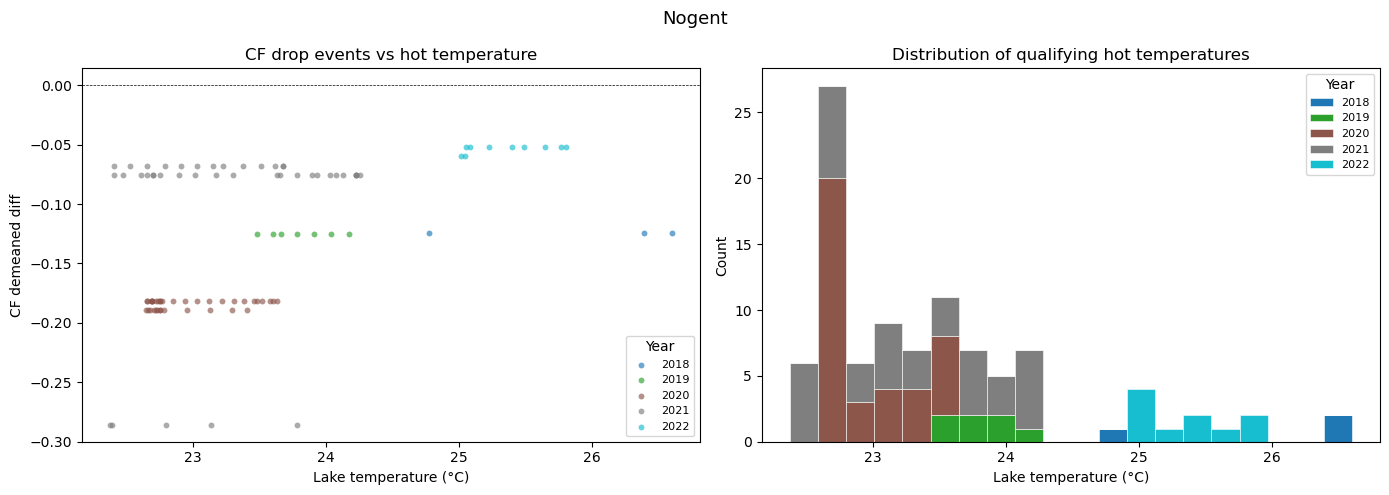

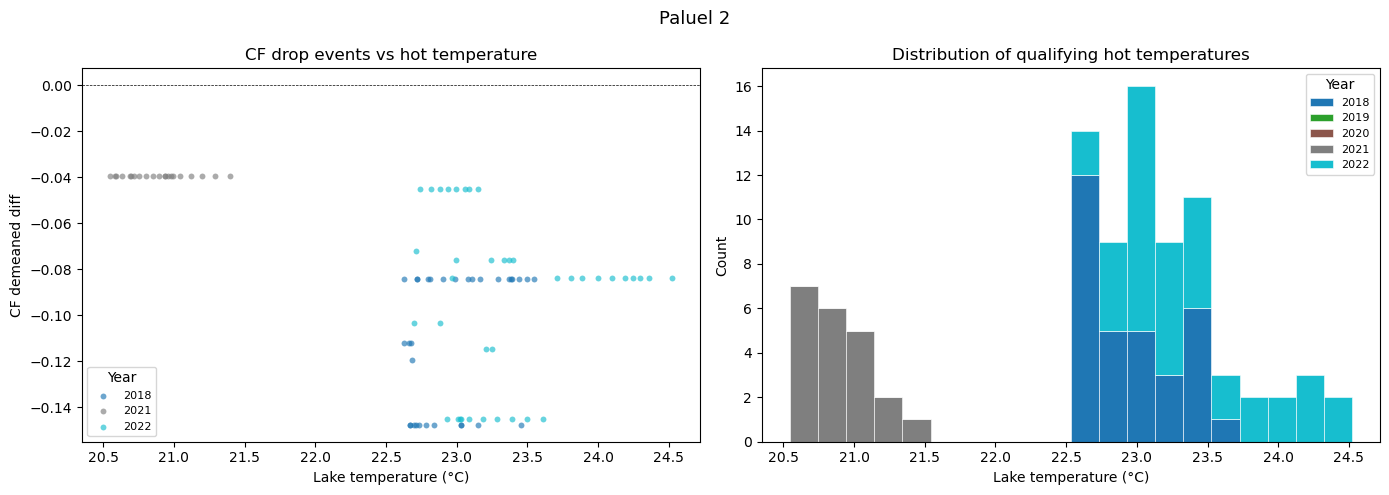

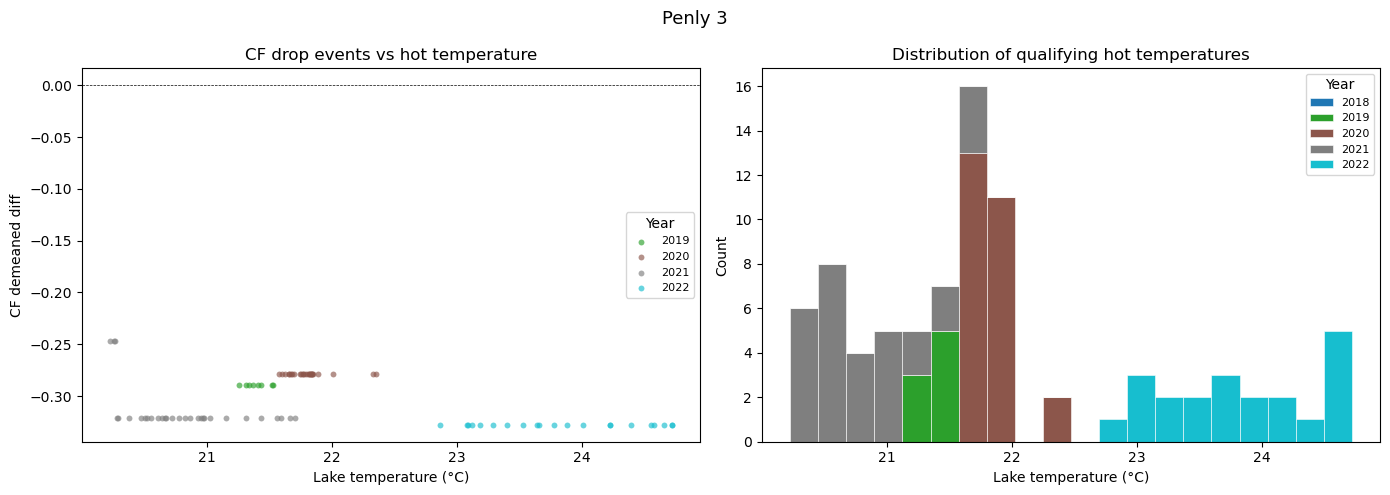

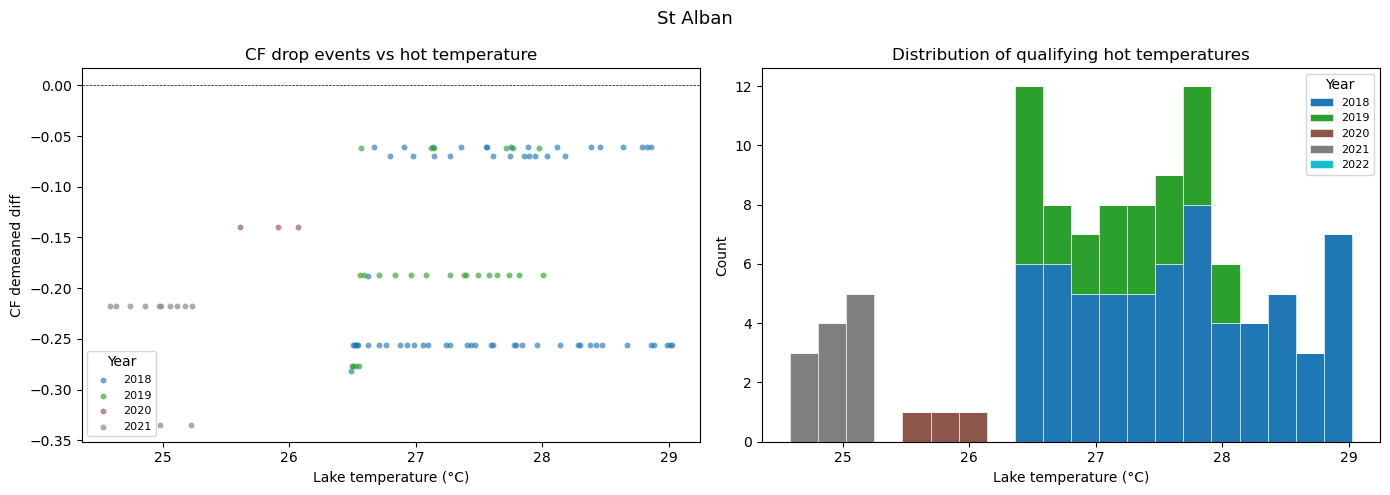

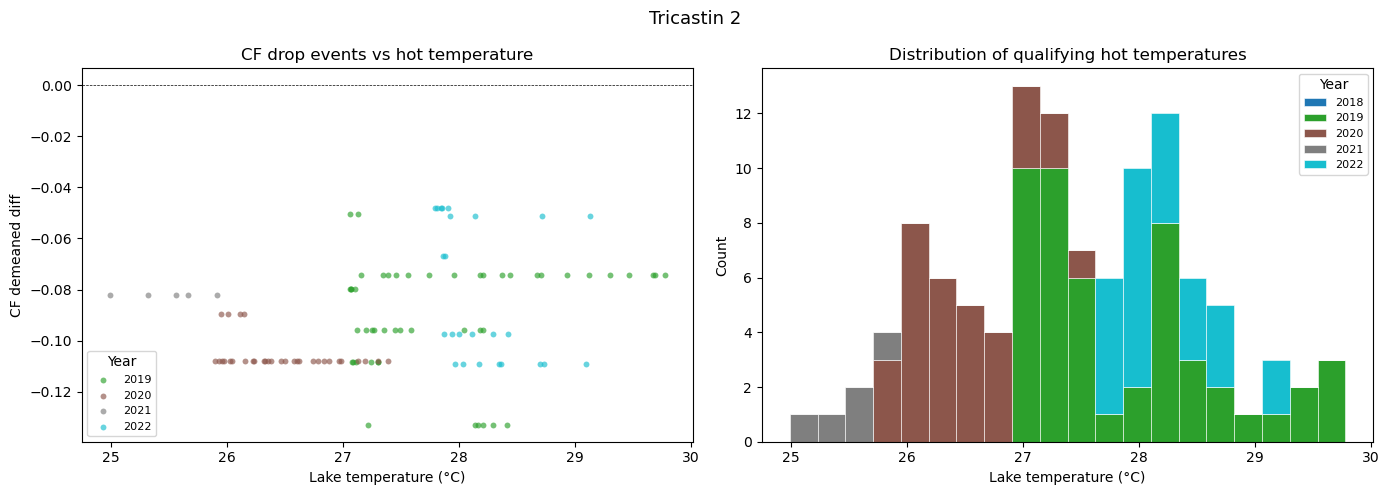

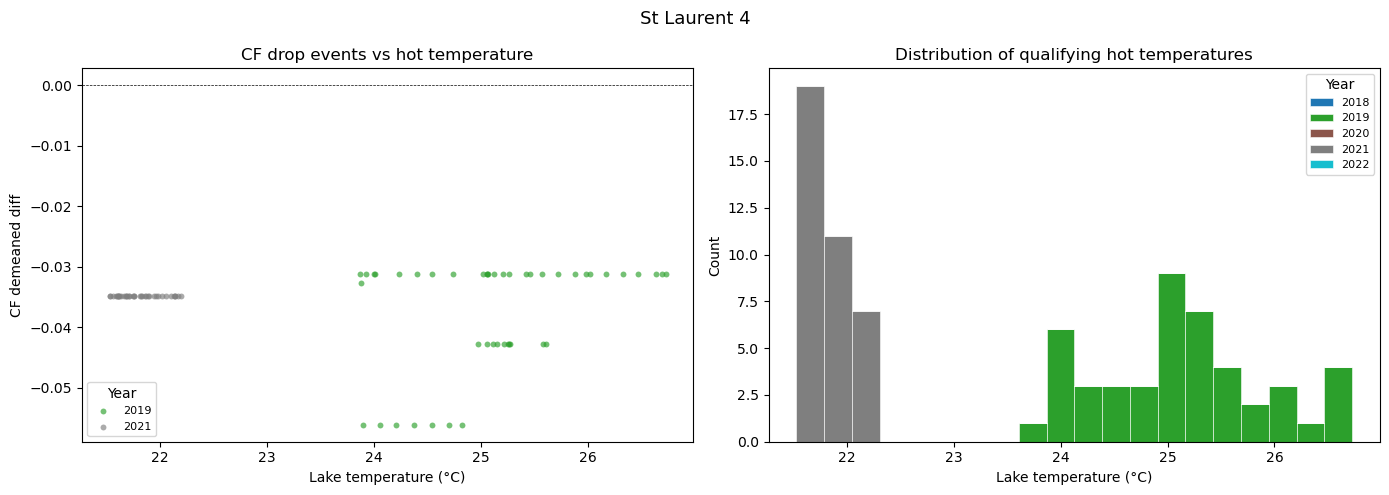

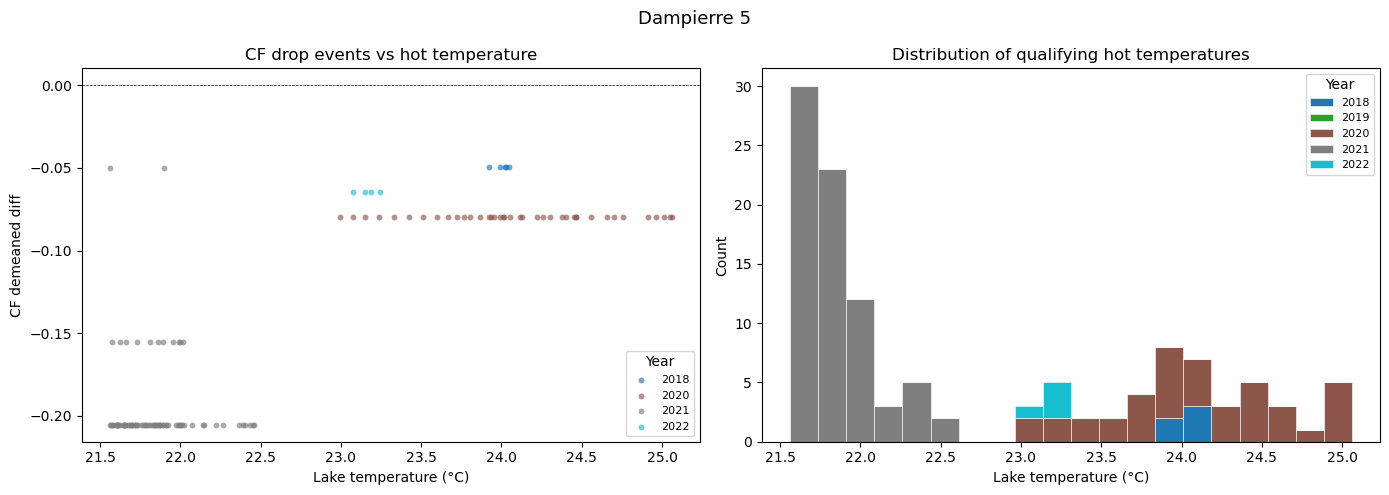

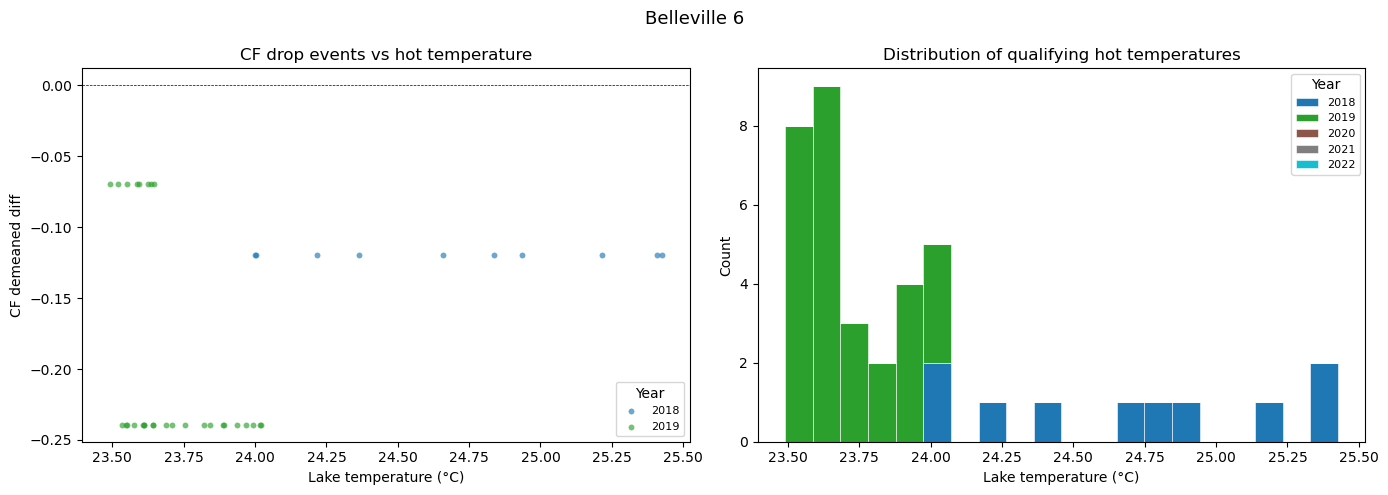

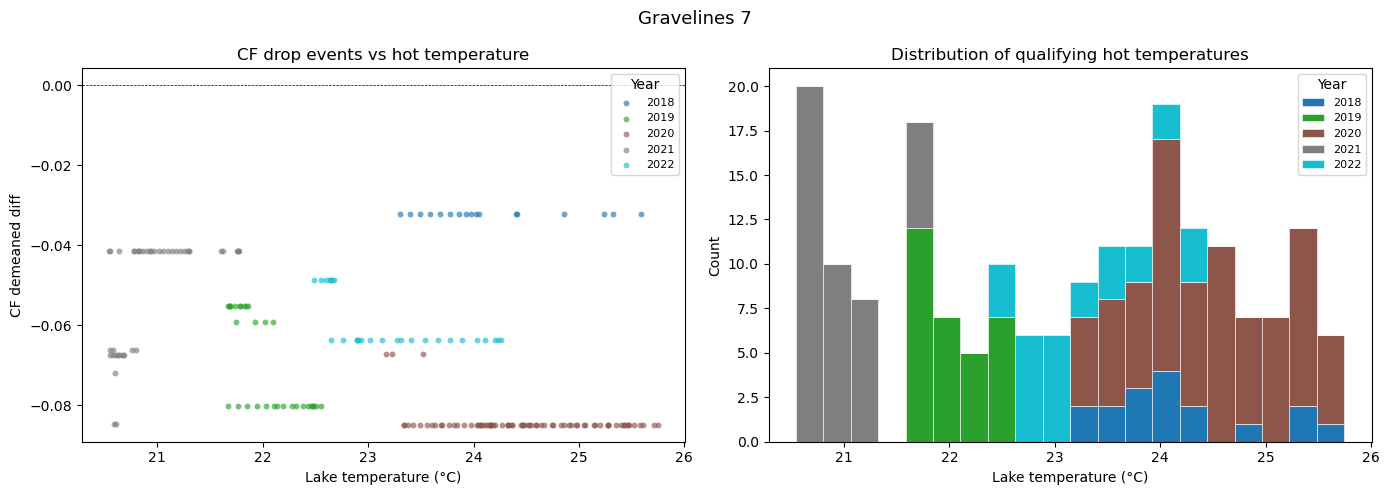

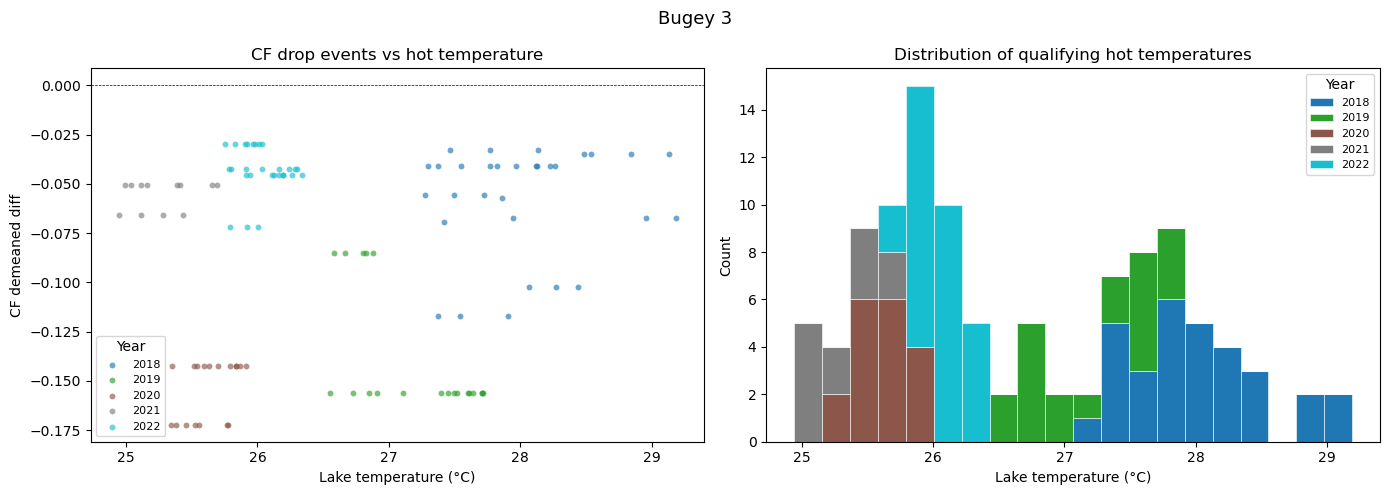

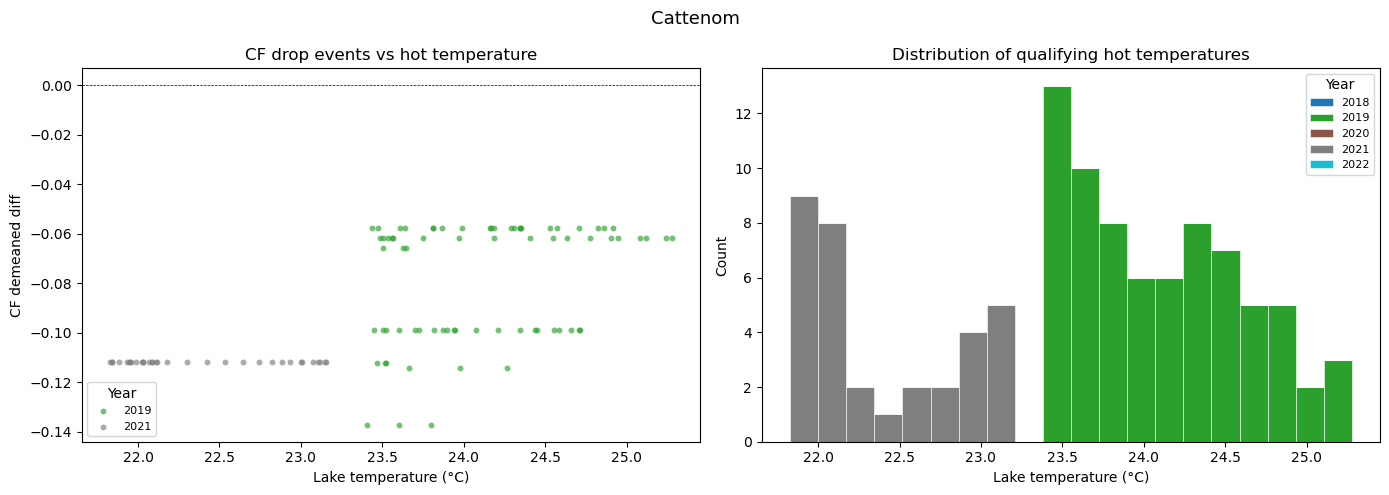

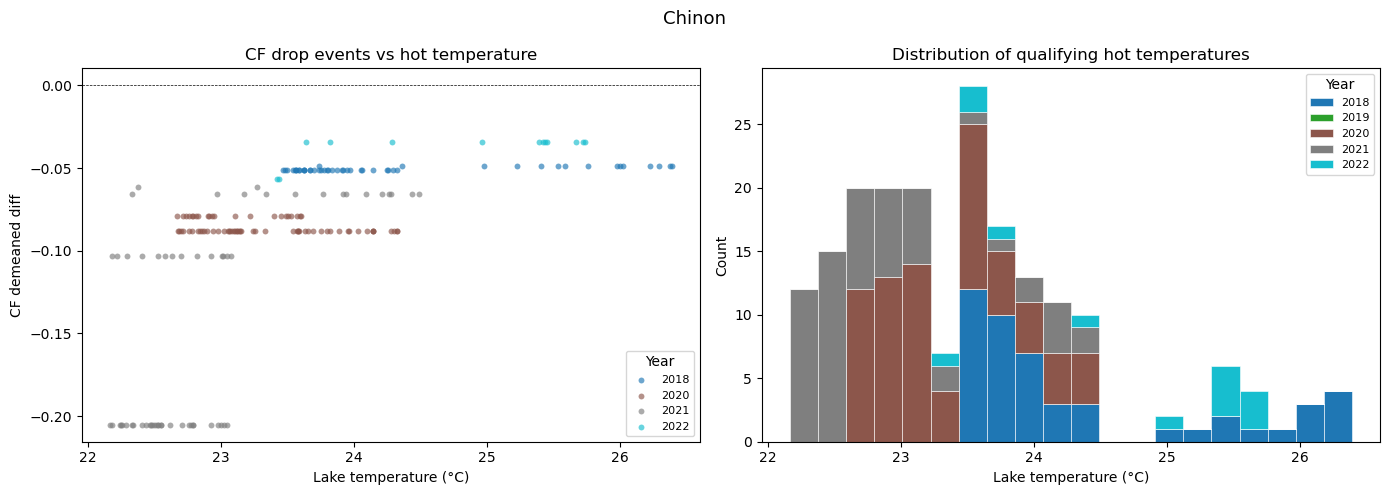

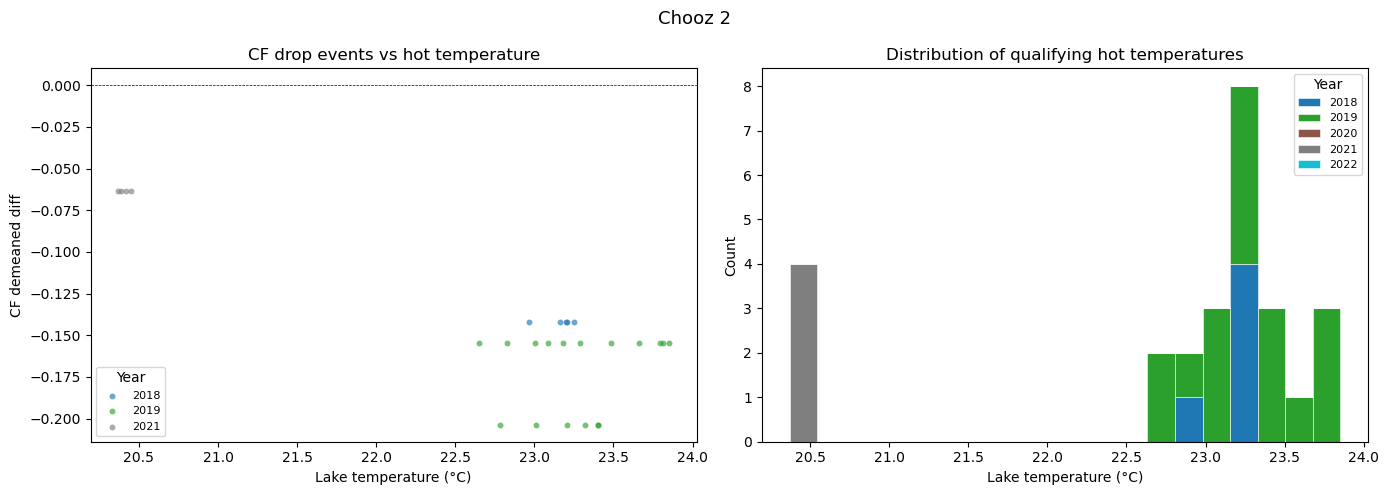

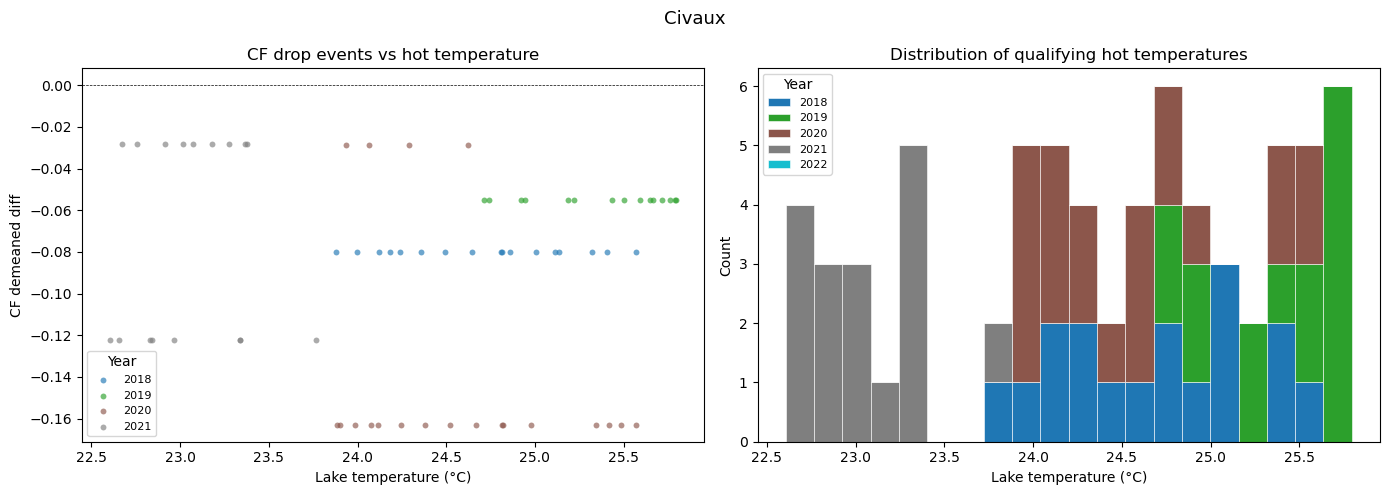

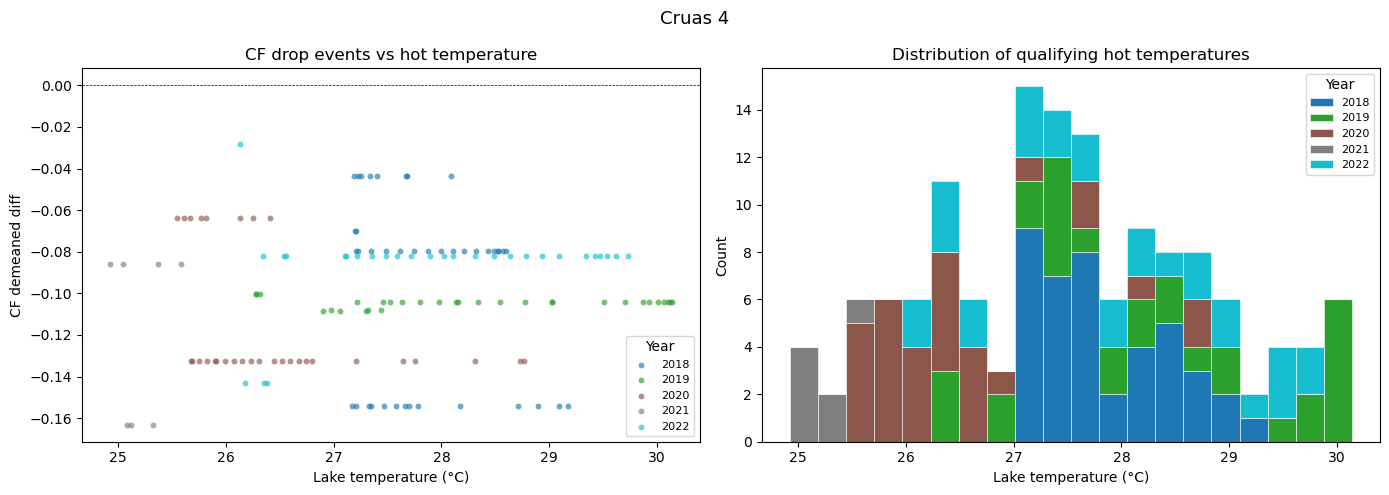

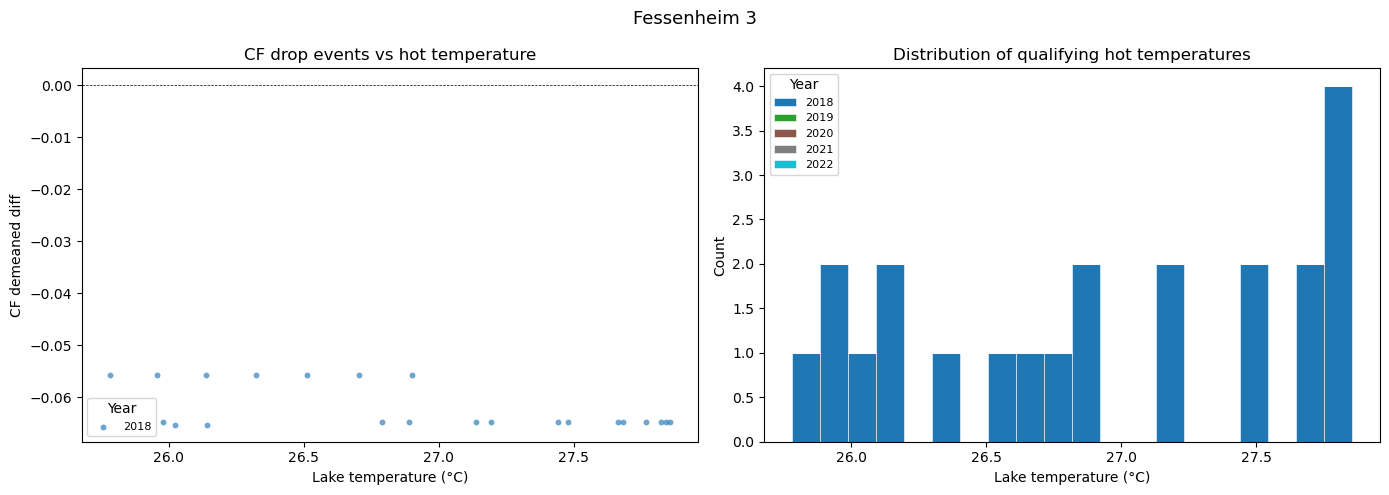

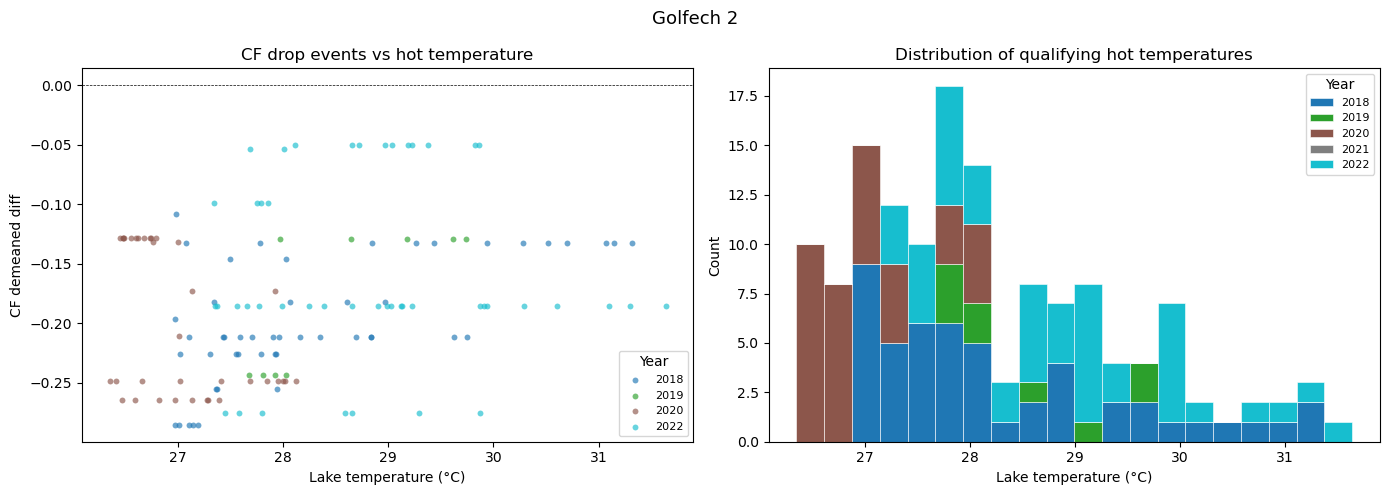

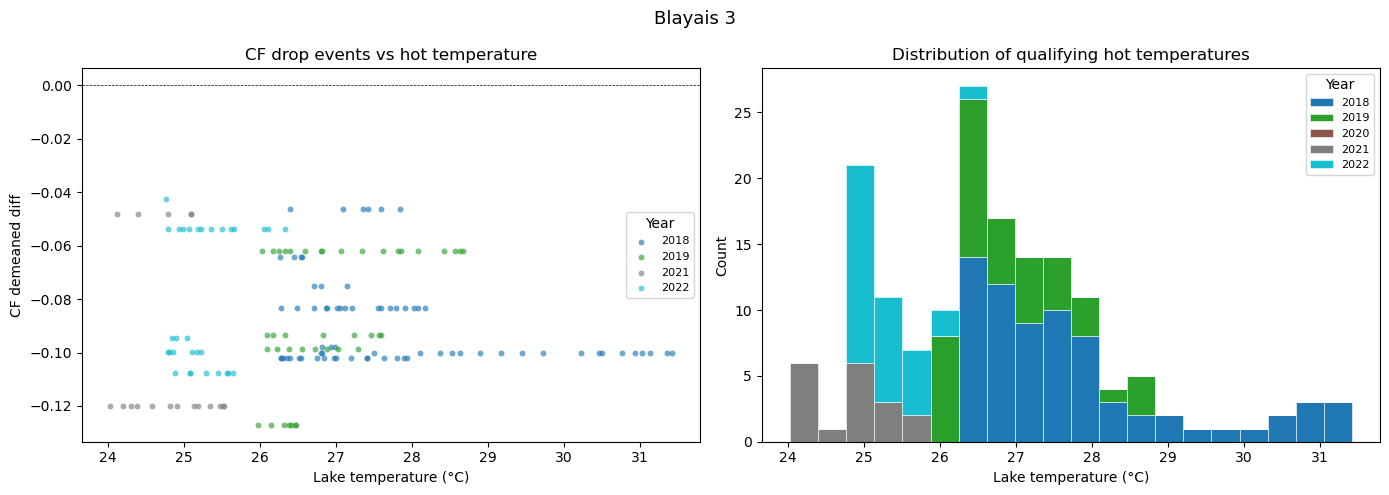

In [15]:
for plant, points in scatter_by_plant.items():
    if not points:
        continue

    df = pd.DataFrame(points, columns=["temp", "diff", "year"])

    fig, (ax_sc, ax_hi) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(plant, fontsize=13)

    # Scatter: CF diff vs qualifying hot temperature
    for yr in year_list:
        sub = df[df["year"] == yr]
        if sub.empty:
            continue
        ax_sc.scatter(sub["temp"], sub["diff"], color=colors[yr], label=str(yr),
                      alpha=0.65, s=18, linewidths=0)
    ax_sc.axhline(0, color="k", linewidth=0.5, linestyle="--")
    ax_sc.set_xlabel("Lake temperature (°C)")
    ax_sc.set_ylabel("CF demeaned diff")
    ax_sc.set_title("CF drop events vs hot temperature")
    ax_sc.legend(title="Year", fontsize=8)

    # Stacked histogram: distribution of qualifying hot temperatures
    temp_arrays = [df[df["year"] == yr]["temp"].values for yr in year_list]
    ax_hi.hist(temp_arrays, bins=20, stacked=True,
               color=[colors[yr] for yr in year_list],
               label=[str(yr) for yr in year_list],
               edgecolor="white", linewidth=0.4)
    ax_hi.set_xlabel("Lake temperature (°C)")
    ax_hi.set_ylabel("Count")
    ax_hi.set_title("Distribution of qualifying hot temperatures")
    ax_hi.legend(title="Year", fontsize=8)

    plt.tight_layout()
    plt.show()

In [25]:
def _merged_spans(idx, pad="36h"):
    """Expand each timestamp by ±pad and merge overlapping intervals."""
    if idx.empty:
        return []
    pad_td = pd.Timedelta(pad)
    intervals = sorted((ts - pad_td, ts + pad_td) for ts in idx)
    spans, start, end = [], intervals[0][0], intervals[0][1]
    for s, e in intervals[1:]:
        if s <= end:
            end = max(end, e)
        else:
            spans.append((start, end))
            start, end = s, e
    spans.append((start, end))
    return spans


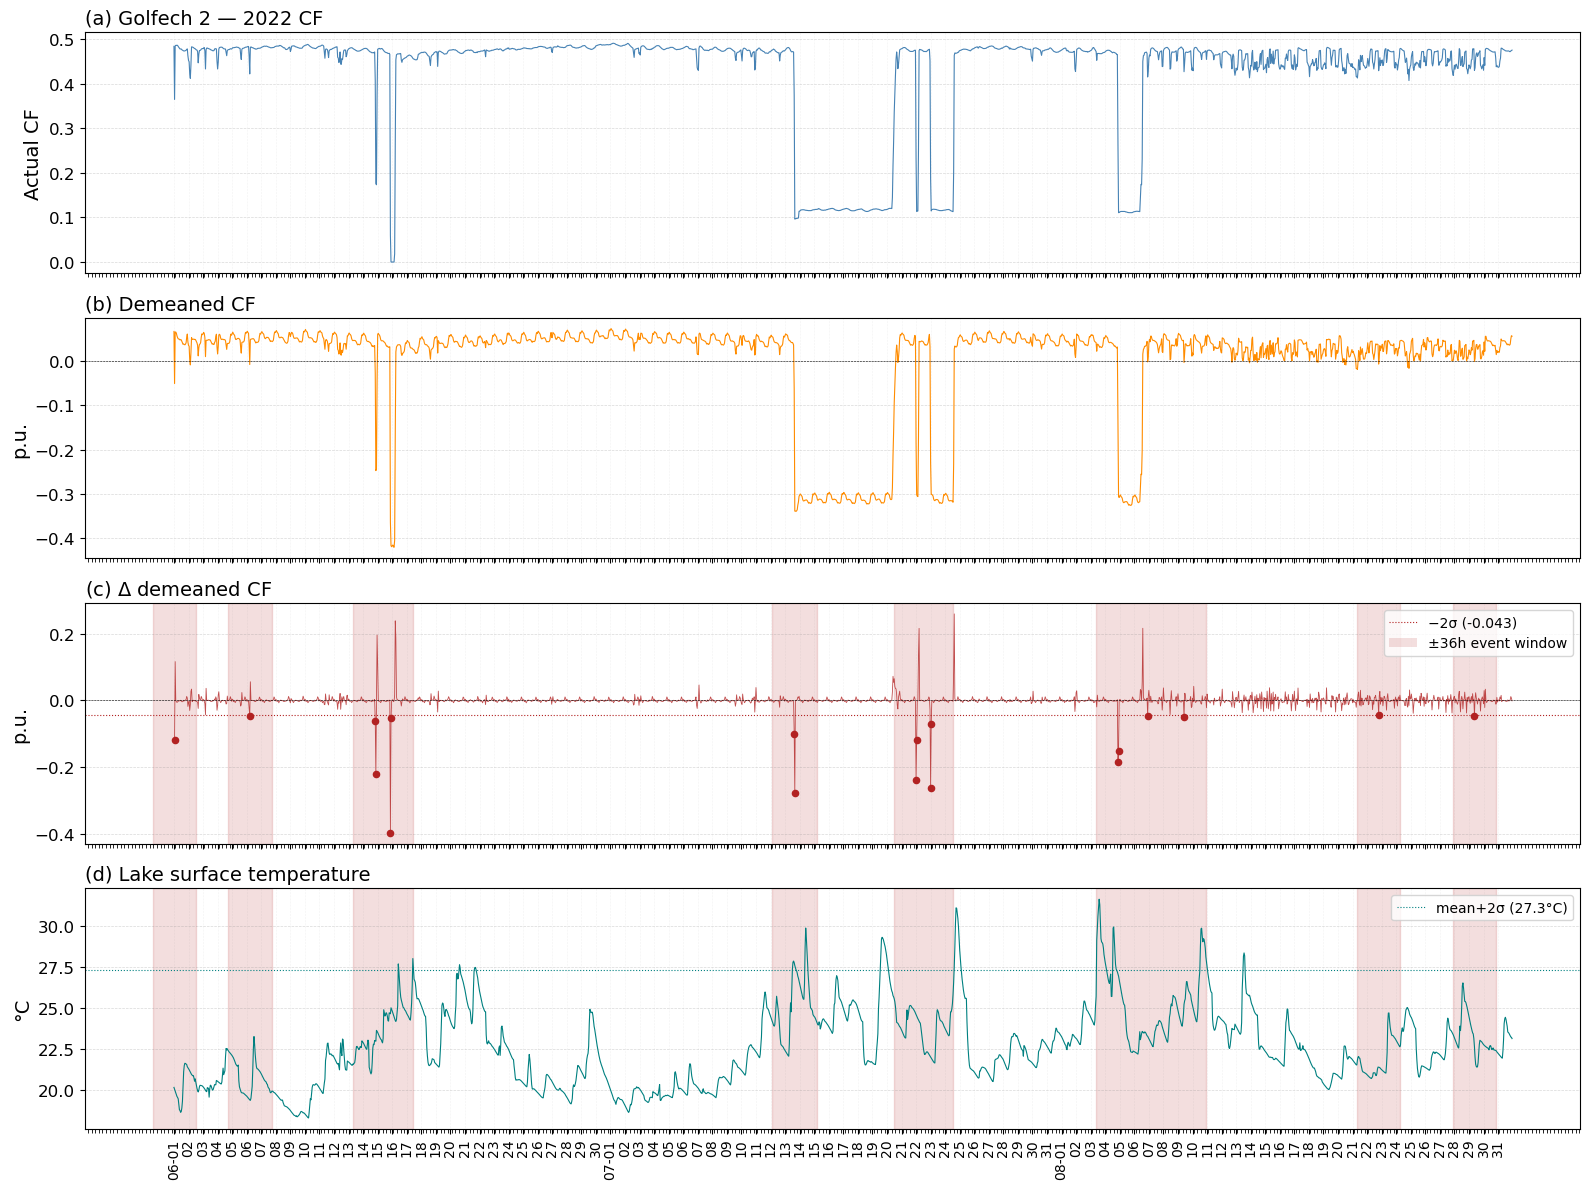

In [26]:
from matplotlib.patches import Patch
import matplotlib.dates as mdates
from styles import _compute_day_ticks


PLANT = "Golfech 2"
YEAR  = 2022

summer_start = f"{YEAR}-06-01"
summer_end   = f"{YEAR}-08-31"

# Raw CF
mapping  = mapping_by_year[YEAR]
cf_src   = cf_filled_by_year[YEAR].loc[summer_start:summer_end]
units    = mapping.loc[mapping["Name"] == PLANT, "unit_name"].tolist()
sub      = cf_src[cf_src["unit_name"].isin(units)]
pivot    = sub.pivot_table(index=sub.index, columns="unit_name", values="capacity_factor")
caps     = sub.groupby("unit_name")["installed_capacity_mw"].first()
cf_raw   = pivot.mul(caps).sum(axis=1) / caps.sum()

cf_dem    = cf_demeaned_by_year[YEAR][PLANT]
cf_diff   = cf_dem.diff()
lake_temp = raw_summer_temp_by_year[YEAR][PLANT]

threshold = cf_diff.mean() - 2 * cf_diff.std()
events    = cf_diff[cf_diff < threshold]

spans = _merged_spans(events.index)

fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)

axes[0].set_title(f"(a) {PLANT} — {YEAR} CF", fontsize=14, loc="left")
axes[0].plot(cf_raw.index,  cf_raw.values,  linewidth=0.8, color="steelblue")
axes[0].set_ylabel("Actual CF")

axes[1].set_title("(b) Demeaned CF", fontsize=14, loc="left")
axes[1].plot(cf_dem.index,  cf_dem.values,  linewidth=0.8, color="darkorange")
axes[1].axhline(0, color="k", linewidth=0.4, linestyle="--")
axes[1].set_ylabel("p.u.")

axes[2].set_title(r"(c) $\Delta$ demeaned CF", fontsize=14, loc="left")
axes[2].plot(cf_diff.index, cf_diff.values, linewidth=0.6, color="firebrick", alpha=0.8)
axes[2].axhline(0, color="k", linewidth=0.4, linestyle="--")
axes[2].axhline(threshold, color="firebrick", linewidth=0.8, linestyle=":", label=f"−2σ ({threshold:.3f})")
axes[2].scatter(events.index, events.values, color="firebrick", s=20, zorder=5)
for s, e in spans:
    axes[2].axvspan(s, e, alpha=0.15, color="firebrick", zorder=0)
    axes[3].axvspan(s, e, alpha=0.15, color="firebrick", zorder=0)
axes[2].set_ylabel("p.u.")
axes[2].legend(
    handles=[
        plt.Line2D([], [], color="firebrick", linestyle=":", linewidth=0.8, label=f"−2σ ({threshold:.3f})"),
        Patch(facecolor="firebrick", alpha=0.15, label="±36h event window"),
    ],
    fontsize=10,
)

axes[3].set_title("(d) Lake surface temperature", fontsize=14, loc="left")
axes[3].plot(lake_temp.index, lake_temp.values, linewidth=0.8, color="teal")
temp_mean, temp_std = temp_stats[YEAR][PLANT]
hot_threshold = temp_mean + 2 * temp_std
axes[3].axhline(hot_threshold, color="teal", linewidth=0.8, linestyle=":", label=f"mean+2σ ({hot_threshold:.1f}°C)")
axes[3].set_ylabel("°C")
axes[3].legend(fontsize=10)

tickvals, ticktext = _compute_day_ticks(cf_raw.index)
axes[-1].set_xticks(tickvals)
axes[-1].set_xticklabels(ticktext, rotation=90, ha="center", fontsize=10)

for ax in axes:
    ax.grid(True, axis="y", which="major", alpha=0.3, linestyle="--", linewidth=0.5, color="grey")
    ax.grid(True, axis="x", which="major", alpha=0.2, linestyle=":", linewidth=0.4, color="grey")
    ax.xaxis.set_minor_locator(mdates.HourLocator(interval=6))
    ax.tick_params(axis="x", which="minor", length=3)

plt.tight_layout()
plt.show()


In [20]:
df_temp = pd.read_csv(pypsa_eur_root / "scripts/_testing/cf_drop_hot_temp_events.csv")
year_list = sorted(df_temp["year"].unique())
cmap = cm.tab10
colors = {yr: cmap(i / max(len(year_list) - 1, 1)) for i, yr in enumerate(year_list)}
plant_river_list = ['Tricastin 2', 'St Alban', 'Bugey 3', 'Blayais 3', 'Golfech 2']

df_temp = df_temp[df_temp['plant'].isin(plant_river_list)]

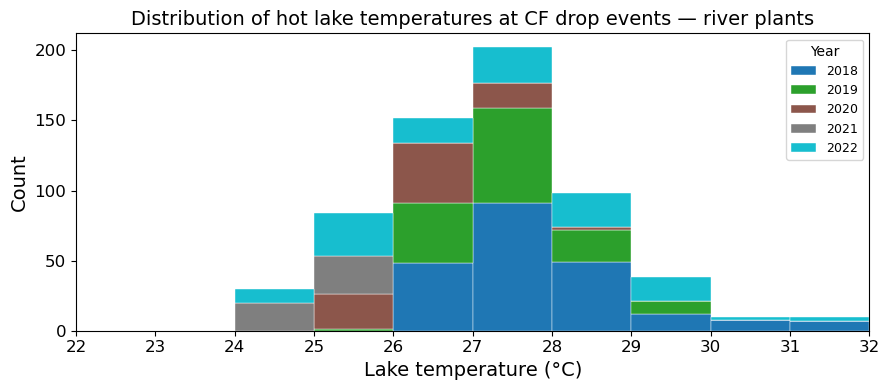

In [27]:
fig, ax = plt.subplots(figsize=(9, 4))
temp_arrays = [df_temp[df_temp["year"] == yr]["lake_temp_c"].values for yr in year_list]
ax.hist(temp_arrays, bins=np.arange(22, 33, 1)
, stacked=True,
        color=[colors[yr] for yr in year_list],
        label=[str(yr) for yr in year_list],
        edgecolor="white", linewidth=0.3)
ax.set_xlabel("Lake temperature (°C)")
ax.set_ylabel("Count")
ax.set_title("Distribution of hot lake temperatures at CF drop events — river plants")
ax.set_xlim(22, 32)
ax.set_xticks(np.arange(22, 33, 1))

ax.legend(title="Year", fontsize=9)
plt.tight_layout()
plt.show()

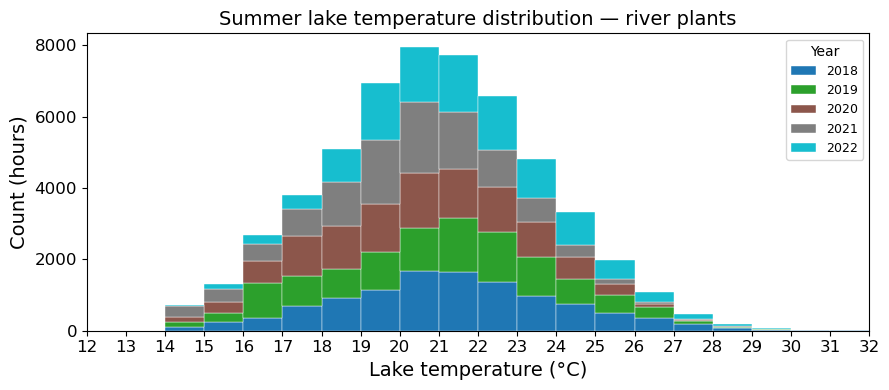

In [141]:
all_summer = lake_temps_df[
    lake_temps_df["plant"].apply(lambda p: _base_name(p) in river_bases) &
    lake_temps_df["snapshot"].dt.month.isin([6, 7, 8])
]


year_list_a = sorted(all_summer["year"].unique())
colors_a    = {yr: cm.tab10(i / max(len(year_list_a) - 1, 1)) for i, yr in enumerate(year_list_a)}

fig, ax = plt.subplots(figsize=(9, 4))
temp_arrays = [all_summer[all_summer["year"] == yr]["lake_temp_c"].values for yr in year_list_a]
ax.hist(temp_arrays, bins=np.arange(14, 36, 1), stacked=True,
        color=[colors_a[yr] for yr in year_list_a],
        label=[str(yr) for yr in year_list_a],
        edgecolor="white", linewidth=0.3)
ax.set_xlim(12, 32)
ax.set_xticks(np.arange(12, 33, 1))
ax.set_xlabel("Lake temperature (°C)")
ax.set_ylabel("Count (hours)")
ax.set_title("Summer lake temperature distribution — river plants")
ax.legend(title="Year", fontsize=9)
plt.tight_layout()
plt.show()


In [131]:
df_temp.plant.unique()

array(['Blayais 3', 'Bugey 3', 'Golfech 2', 'St Alban', 'Tricastin 2'],
      dtype=object)

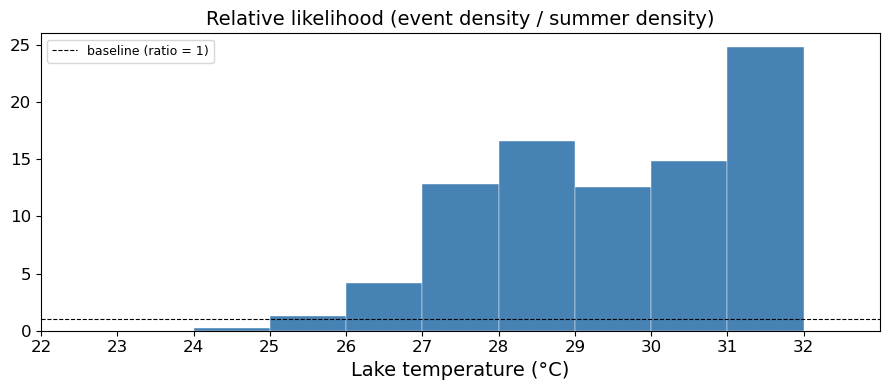

In [29]:
# Background: all summer lake temps for the same river plants and years
river_bases = {_base_name(p) for p in plant_river_list}
background = lake_temps_df[
    lake_temps_df["plant"].apply(lambda p: _base_name(p) in river_bases) &
    lake_temps_df["snapshot"].dt.month.isin([6, 7, 8]) &
    lake_temps_df["year"].isin(year_list)
]["lake_temp_c"].values

event_temps = df_temp["lake_temp_c"].values

# Common bins across both distributions
t_max = max(event_temps.max(), background.max())
bins  = np.arange(22, np.ceil(t_max) + 1, 1)  # 1°C bins from 20°C

bin_centers = (bins[:-1] + bins[1:]) / 2

# Density-normalise each histogram so sample sizes don't bias the ratio
event_dens,  _ = np.histogram(event_temps, bins=bins, density=True)
bg_dens,     _ = np.histogram(background,  bins=bins, density=True)

ratio = np.where(bg_dens > 0, event_dens / bg_dens, np.nan)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(bin_centers, ratio, width=np.diff(bins),
       color="steelblue", edgecolor="white", linewidth=0.3)
ax.set_xlim(22, 33)
ax.set_xticks(np.arange(22, 33, 1))

ax.axhline(1, color="k", linewidth=0.8, linestyle="--", label="baseline (ratio = 1)")
ax.set_xlabel("Lake temperature (°C)")
ax.set_title("Relative likelihood (event density / summer density)", fontsize=14)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


/tmp/ipykernel_1082494/632428406.py:16: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



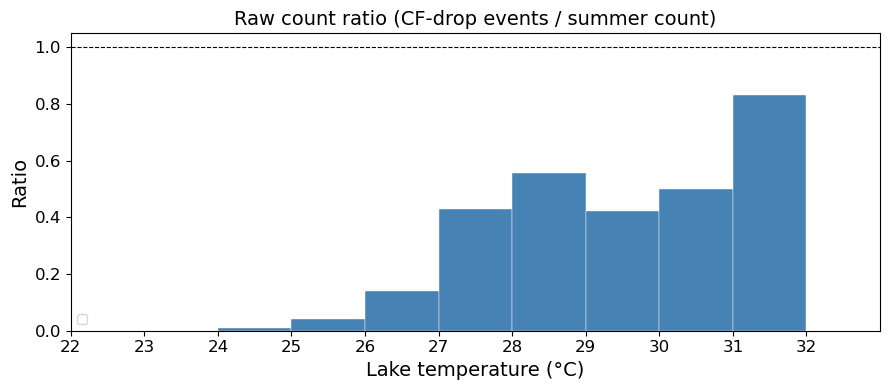

In [35]:
event_counts, _ = np.histogram(event_temps, bins=bins)
bg_counts,    _ = np.histogram(background,  bins=bins)

ratio = np.where(bg_counts > 0, event_counts / bg_counts, np.nan)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(bin_centers, ratio, width=np.diff(bins),
       color="steelblue", edgecolor="white", linewidth=0.3)
ax.set_xlim(22, 33)
ax.set_xticks(np.arange(22, 33, 1))

ax.axhline(1, color="k", linewidth=0.8, linestyle="--")
ax.set_xlabel("Lake temperature (°C)")
ax.set_ylabel("Ratio")
ax.set_title("Raw count ratio (CF-drop events / summer count)", fontsize=14)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


In [147]:
event_dens

array([0.        , 0.        , 0.04807692, 0.13461538, 0.24358974,
       0.32371795, 0.15705128, 0.06089744, 0.01602564, 0.01602564])

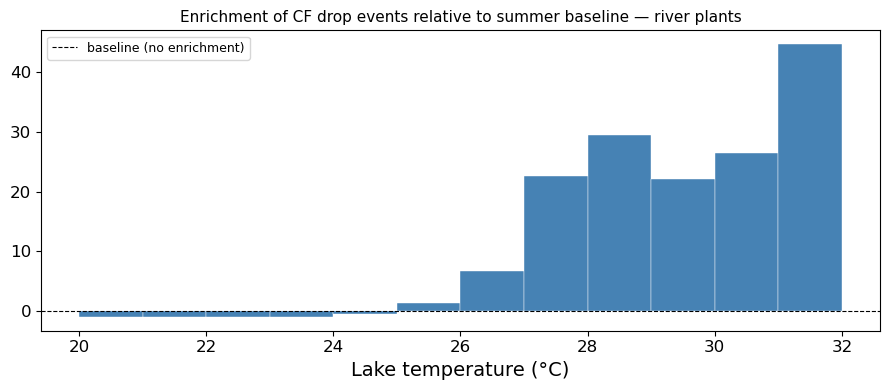

In [124]:
# Background: all summer lake temps for the same river plants and years
river_bases = {_base_name(p) for p in plant_river_list}
background = lake_temps_df[
    lake_temps_df["plant"].apply(lambda p: _base_name(p) in river_bases) &
    lake_temps_df["snapshot"].dt.month.isin([6, 7, 8]) &
    lake_temps_df["year"].isin(year_list)
]["lake_temp_c"].values

event_temps = df_temp["lake_temp_c"].values

t_max = max(event_temps.max(), background.max())
bins  = np.arange(20, np.ceil(t_max) + 1, 1)

bin_centers = (bins[:-1] + bins[1:]) / 2

event_counts, _ = np.histogram(event_temps, bins=bins)
bg_counts,    _ = np.histogram(background,  bins=bins)

event_norm = event_counts / event_counts.sum()
bg_norm    = bg_counts    / bg_counts.sum()

ratio = np.where(bg_norm > 0, (event_norm - bg_norm) / bg_norm, np.nan)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(bin_centers, ratio, width=np.diff(bins),
       color="steelblue", edgecolor="white", linewidth=0.3)
ax.axhline(0, color="k", linewidth=0.8, linestyle="--", label="baseline (no enrichment)")
ax.set_xlabel("Lake temperature (°C)")
ax.set_title("Enrichment of CF drop events relative to summer baseline — river plants", fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


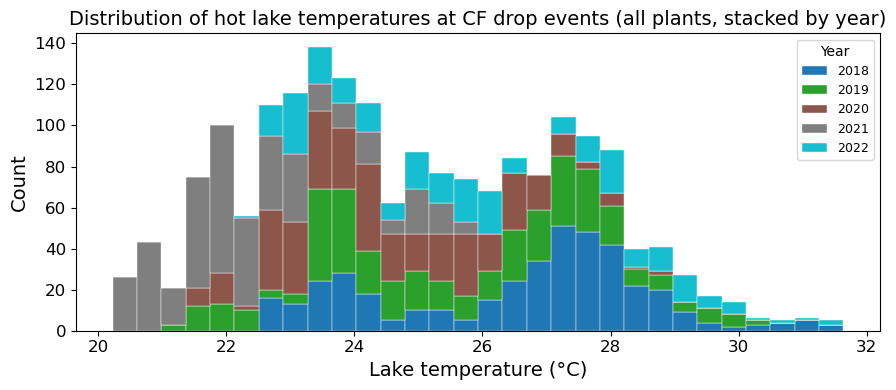

In [121]:
df_temp_all = pd.read_csv(pypsa_eur_root / "scripts/_testing/cf_drop_hot_temp_events.csv")
year_list_all = sorted(df_temp_all["year"].unique())
colors_all = {yr: cm.tab10(i / max(len(year_list_all) - 1, 1)) for i, yr in enumerate(year_list_all)}

fig, ax = plt.subplots(figsize=(9, 4))
temp_arrays = [df_temp_all[df_temp_all["year"] == yr]["lake_temp_c"].values for yr in year_list_all]
ax.hist(temp_arrays, bins=30, stacked=True,
        color=[colors_all[yr] for yr in year_list_all],
        label=[str(yr) for yr in year_list_all],
        edgecolor="white", linewidth=0.3)
ax.set_xlabel("Lake temperature (°C)")
ax.set_ylabel("Count")
ax.set_title("Distribution of hot lake temperatures at CF drop events (all plants, stacked by year)")
ax.legend(title="Year", fontsize=9)
plt.tight_layout()
plt.show()


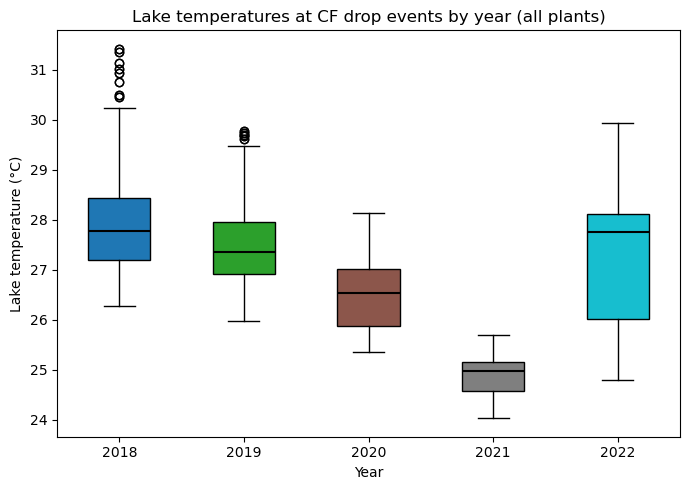

In [44]:
fig, ax = plt.subplots(figsize=(7, 5))
data_by_year = [df_temp[df_temp["year"] == yr]["lake_temp_c"].values for yr in year_list]
bp = ax.boxplot(data_by_year, patch_artist=True, medianprops=dict(color="black", linewidth=1.5))
for patch, yr in zip(bp["boxes"], year_list):
    patch.set_facecolor(colors[yr])
ax.set_xticklabels([str(yr) for yr in year_list])
ax.set_xlabel("Year")
ax.set_ylabel("Lake temperature (°C)")
ax.set_title("Lake temperatures at CF drop events by year (all plants)")
plt.tight_layout()
plt.show()

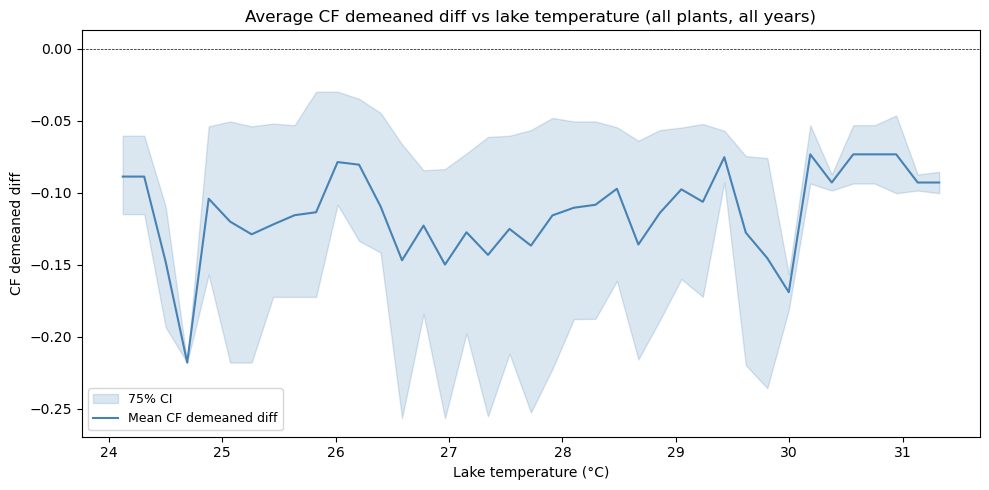

In [45]:
bins = np.linspace(df_temp["lake_temp_c"].min(), df_temp["lake_temp_c"].max(), 40)
df_temp["temp_bin"] = pd.cut(df_temp["lake_temp_c"], bins=bins)
bin_stats = df_temp.groupby("temp_bin", observed=True)["cf_demeaned_diff"].agg(
    mean="mean",
    q_low=lambda x: x.quantile(0.125),
    q_high=lambda x: x.quantile(0.875),
)
bin_centers = bins[:-1] + np.diff(bins) / 2

fig, ax = plt.subplots(figsize=(10, 5))
ax.fill_between(bin_centers, bin_stats["q_low"], bin_stats["q_high"],
                alpha=0.2, color="steelblue", label="75% CI")
ax.plot(bin_centers, bin_stats["mean"], color="steelblue", linewidth=1.5, label="Mean CF demeaned diff")
ax.axhline(0, color="k", linewidth=0.5, linestyle="--")
ax.set_xlabel("Lake temperature (°C)")
ax.set_ylabel("CF demeaned diff")
ax.set_title("Average CF demeaned diff vs lake temperature (all plants, all years)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


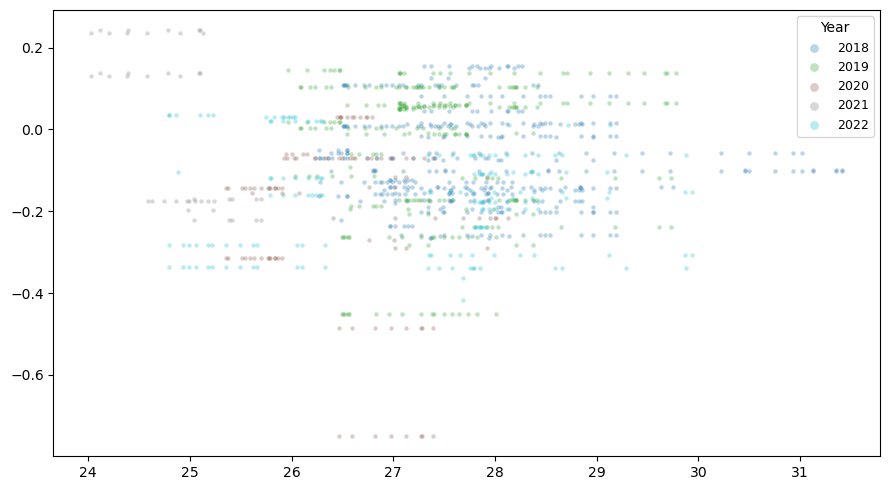

In [46]:
fig, ax = plt.subplots(figsize=(9, 5))

for yr in year_list:
    sub = df_temp[df_temp["year"] == yr]
    ax.scatter(sub["lake_temp_c"], sub["cf_demeaned"],
               alpha=0.3, s=10, linewidths=0, color=colors[yr], label=str(yr))
ax.legend(title="Year", fontsize=9, markerscale=2)
plt.tight_layout()
plt.show()

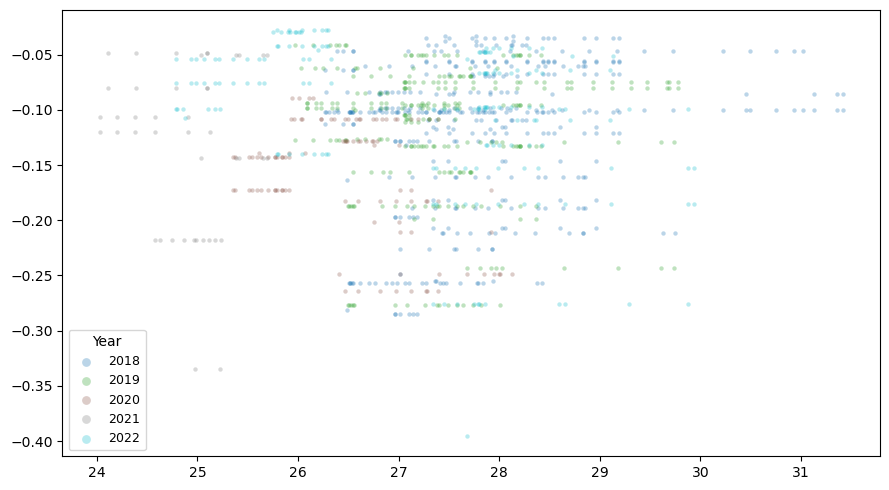

In [47]:
fig, ax = plt.subplots(figsize=(9, 5))

for yr in year_list:
    sub = df_temp[df_temp["year"] == yr]
    ax.scatter(sub["lake_temp_c"], sub["cf_demeaned_diff"],
               alpha=0.3, s=10, linewidths=0, color=colors[yr], label=str(yr))
ax.legend(title="Year", fontsize=9, markerscale=2)
plt.tight_layout()
plt.show()

In [39]:
df_temp.plant.unique()

array(['Belleville 6', 'Blayais 3', 'Bugey 3', 'Cattenom', 'Chinon',
       'Chooz 2', 'Civaux', 'Cruas 4', 'Dampierre 5', 'Fessenheim 3',
       'Golfech 2', 'Gravelines 7', 'Nogent', 'Paluel 2', 'Penly 3',
       'St Alban', 'St Laurent 4', 'Tricastin 2'], dtype=object)

In [40]:
plant_river_list = ['Tricastin 2', 'St Alban', 'Bugey 3', 'Blayais 3', 'Golfech 2']

In [41]:
df_temp[df_temp['plant'].isin(plant_river_list)].lake_temp_c.describe()

count    990.000000
mean      27.374485
std        1.191139
min       24.027008
25%       26.597809
50%       27.407867
75%       28.060211
max       31.416656
Name: lake_temp_c, dtype: float64